In [70]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf
from patsy import dmatrix
import statsmodels.api as sm

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from catboost import CatBoostRegressor, Pool

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)
sns.set_theme(style="whitegrid")


In [2]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = True
USE_DIVISION = True

WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]
WIND_GUST_ORDER = ["low", "mild", "high", "very_high"]
DIVISION_ORDER = ["MA4", "MA3", "MA2", "MA1", "MPO"]

CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 20000,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

print("Using local round dataset:", ROUND_DATA_PATH)


Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet


In [3]:
# -----------------------------------------------------------------------------
# Config
# -----------------------------------------------------------------------------

OUTPUT_DIR = Path.cwd() / "notebook_exports"
ROUND_DATA_PATH = OUTPUT_DIR / "round_level_modeling_dataset_v1.parquet"

TEST_SIZE = 0.20
VALID_SIZE_WITHIN_TRAIN = 0.20
RANDOM_STATE = 42

USE_LAYOUT_ID = True
USE_DIVISION = True

WIND_SPEED_ORDER = ["calm", "light", "moderate", "strong"]
WIND_GUST_ORDER = ["low", "mild", "high", "very_high"]
DIVISION_ORDER = ["MA4", "MA3", "MA2", "MA1", "MPO"]

CATBOOST_PARAMS = {
    "loss_function": "RMSE",
    "eval_metric": "RMSE",
    "iterations": 20000,
    "depth": 6,
    "learning_rate": 0.05,
    "l2_leaf_reg": 5.0,
    "random_seed": RANDOM_STATE,
    "verbose": 250,
    "bootstrap_type": "Bernoulli",
    "subsample": 0.8,
    "max_ctr_complexity": 1,
    "store_all_simple_ctr": False,
    "task_type": "CPU",
}

print("Using local round dataset:", ROUND_DATA_PATH)


Using local round dataset: c:\Users\ryanc\dg_wind_effects\wind_impact_analysis\notebook_exports\round_level_modeling_dataset_v1.parquet


In [4]:
# -----------------------------------------------------------------------------
# Load local round dataset
# -----------------------------------------------------------------------------

round_level_df = pd.read_parquet(ROUND_DATA_PATH)

print("Round-level shape:", round_level_df.shape)
round_level_df.head()


Round-level shape: (419842, 28)


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating
0,2025,90004,1,PDGA#240866,248066,731340,MA4,777.0,60.0,18,4262.0,236.777778,54.0,3.000000,2.99,2.99,5.3,5.3,15.6,0.0,0.0,1018.5,82.0,6.0,78.925926,12743.38,22588.6,2323.23
1,2025,90022,1,PDGA#139372,303386,708703,MPO,944.0,65.0,22,6640.0,301.818182,69.0,3.136364,0.69,0.69,3.0,3.0,3.7,0.0,0.0,1009.0,83.0,-4.0,96.231884,4581.60,19920.0,651.36
2,2025,90022,1,PDGA#178707,303386,708703,FPO,921.0,67.0,22,6640.0,301.818182,69.0,3.136364,1.38,1.38,2.7,2.7,1.1,0.0,0.0,1009.0,91.0,-2.0,96.231884,9163.20,17928.0,1270.98
3,2025,90022,1,PDGA#235527,303386,708703,MA2,861.0,72.0,22,6640.0,301.818182,69.0,3.136364,1.25,1.25,2.3,2.3,2.2,0.0,0.0,1009.7,89.0,3.0,96.231884,8300.00,15272.0,1076.25
4,2025,90022,2,PDGA#208891,303386,708709,MA50,887.0,79.0,22,7337.0,333.500000,70.0,3.181818,1.71,1.71,4.2,4.2,5.5,0.0,0.0,1004.7,77.0,9.0,104.814286,12546.27,30815.4,1516.77


In [5]:
# -----------------------------------------------------------------------------
# Wind bucket helpers
# -----------------------------------------------------------------------------

def wind_speed_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 2.0:
        return "calm"
    if speed < 5.0:
        return "light"
    if speed < 8.0:
        return "moderate"
    if speed < 12.0:
        return "strong"
    return "very_strong"


def wind_gust_bucket(speed: float | None) -> str:
    if pd.isna(speed):
        return "unknown"
    if speed < 3.0:
        return "low"
    if speed < 6.0:
        return "mild"
    if speed < 10.0:
        return "high"
    return "very_high"


In [6]:
# -----------------------------------------------------------------------------
# Feature engineering / cleanup
# -----------------------------------------------------------------------------

model_df = round_level_df.copy()

if "round_wind_speed_bucket" not in model_df.columns:
    model_df["round_wind_speed_bucket"] = model_df["round_wind_speed_mps_mean"].apply(wind_speed_bucket)

if "round_wind_gust_bucket" not in model_df.columns:
    model_df["round_wind_gust_bucket"] = model_df["round_wind_gust_mps_mean"].apply(wind_gust_bucket)

# Ensure interaction features exist
if "wind_x_round_length" not in model_df.columns:
    model_df["wind_x_round_length"] = model_df["round_wind_speed_mps_mean"] * model_df["round_total_hole_length"]

if "gust_x_round_length" not in model_df.columns:
    model_df["gust_x_round_length"] = model_df["round_wind_gust_mps_mean"] * model_df["round_total_hole_length"]

if "wind_x_player_rating" not in model_df.columns:
    model_df["wind_x_player_rating"] = model_df["round_wind_speed_mps_mean"] * model_df["player_rating"]

model_df = model_df.dropna(
    subset=[
        "actual_round_strokes",
        "player_rating",
        "course_id",
        "round_total_hole_length",
        "round_total_par",
        "round_wind_speed_mps_mean",
        "round_wind_gust_mps_mean",
        "round_temp_c_mean",
        "round_precip_mm_mean",
    ]
).copy()

model_df["course_id"] = model_df["course_id"].astype("string")
model_df["layout_id"] = model_df["layout_id"].astype("string")
model_df["division"] = model_df["division"].astype("string")
model_df["round_wind_speed_bucket"] = model_df["round_wind_speed_bucket"].astype("string")
model_df["round_wind_gust_bucket"] = model_df["round_wind_gust_bucket"].astype("string")

print("Model dataframe shape:", model_df.shape)


Model dataframe shape: (419842, 30)


In [7]:
# -----------------------------------------------------------------------------
# Train / validation / test split
# -----------------------------------------------------------------------------

train_full_df, test_df = train_test_split(
    model_df,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
)

train_df, valid_df = train_test_split(
    train_full_df,
    test_size=VALID_SIZE_WITHIN_TRAIN,
    random_state=RANDOM_STATE,
)

print("Train rows:", len(train_df))
print("Valid rows:", len(valid_df))
print("Test rows: ", len(test_df))


Train rows: 268698
Valid rows: 67175
Test rows:  83969


In [8]:
# -----------------------------------------------------------------------------
# Shared helpers
# -----------------------------------------------------------------------------

def regression_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def prepare_catboost_frame(
    train_df: pd.DataFrame,
    valid_df: pd.DataFrame,
    test_df: pd.DataFrame,
    numeric_features: list[str],
    categorical_features: list[str],
    target_col: str,
):
    train_prepped = train_df.copy()
    valid_prepped = valid_df.copy()
    test_prepped = test_df.copy()

    for col in numeric_features + [target_col]:
        train_prepped[col] = pd.to_numeric(train_prepped[col], errors="coerce")
        valid_prepped[col] = pd.to_numeric(valid_prepped[col], errors="coerce")
        test_prepped[col] = pd.to_numeric(test_prepped[col], errors="coerce")

    train_prepped = train_prepped.dropna(subset=numeric_features + [target_col]).copy()
    valid_prepped = valid_prepped.dropna(subset=numeric_features + [target_col]).copy()
    test_prepped = test_prepped.dropna(subset=numeric_features + [target_col]).copy()

    for col in categorical_features:
        train_prepped[col] = train_prepped[col].astype("string").fillna("__MISSING__").astype(str)
        valid_prepped[col] = valid_prepped[col].astype("string").fillna("__MISSING__").astype(str)
        test_prepped[col] = test_prepped[col].astype("string").fillna("__MISSING__").astype(str)

        train_levels = set(train_prepped[col].unique())
        valid_prepped[col] = valid_prepped[col].where(valid_prepped[col].isin(train_levels), "__MISSING__")
        test_prepped[col] = test_prepped[col].where(test_prepped[col].isin(train_levels), "__MISSING__")

    feature_cols = numeric_features + categorical_features
    cat_idx = [feature_cols.index(c) for c in categorical_features]

    train_pool = Pool(train_prepped[feature_cols], label=train_prepped[target_col], cat_features=cat_idx)
    valid_pool = Pool(valid_prepped[feature_cols], label=valid_prepped[target_col], cat_features=cat_idx)
    test_pool = Pool(test_prepped[feature_cols], label=test_prepped[target_col], cat_features=cat_idx)

    return train_prepped, valid_prepped, test_prepped, train_pool, valid_pool, test_pool, feature_cols, cat_idx


In [9]:
# -----------------------------------------------------------------------------
# Feature set definitions
# -----------------------------------------------------------------------------

base_numeric_features = [
    "player_rating",
    "round_number",
    "hole_count",
    "round_total_hole_length",
    "round_avg_hole_length",
    "round_total_par",
    "round_avg_hole_par",
    "round_length_over_par",
    "round_wind_speed_mps_mean",
    "round_wind_speed_mps_max",
    "round_wind_gust_mps_mean",
    "round_wind_gust_mps_max",
    "round_temp_c_mean",
    "round_precip_mm_sum",
    "round_precip_mm_mean",
    "round_pressure_hpa_mean",
    "round_humidity_pct_mean",
]

wind_interaction_features = [
    "wind_x_round_length",
    "gust_x_round_length",
    "wind_x_player_rating",
]

base_categorical_features = [
    "course_id",
    "round_wind_speed_bucket",
    "round_wind_gust_bucket",
]

if USE_DIVISION and model_df["division"].notna().any():
    base_categorical_features.append("division")

if USE_LAYOUT_ID and model_df["layout_id"].notna().any():
    base_categorical_features.append("layout_id")

EXPERIMENTS = [
    {
        "name": "full_model",
        "numeric_features": base_numeric_features + wind_interaction_features,
        "categorical_features": base_categorical_features,
    },
    {
        "name": "no_wind_interactions",
        "numeric_features": base_numeric_features,
        "categorical_features": base_categorical_features,
    },
]

EXPERIMENTS


[{'name': 'full_model',
  'numeric_features': ['player_rating',
   'round_number',
   'hole_count',
   'round_total_hole_length',
   'round_avg_hole_length',
   'round_total_par',
   'round_avg_hole_par',
   'round_length_over_par',
   'round_wind_speed_mps_mean',
   'round_wind_speed_mps_max',
   'round_wind_gust_mps_mean',
   'round_wind_gust_mps_max',
   'round_temp_c_mean',
   'round_precip_mm_sum',
   'round_precip_mm_mean',
   'round_pressure_hpa_mean',
   'round_humidity_pct_mean',
   'wind_x_round_length',
   'gust_x_round_length',
   'wind_x_player_rating'],
  'categorical_features': ['course_id',
   'round_wind_speed_bucket',
   'round_wind_gust_bucket',
   'division',
   'layout_id']},
 {'name': 'no_wind_interactions',
  'numeric_features': ['player_rating',
   'round_number',
   'hole_count',
   'round_total_hole_length',
   'round_avg_hole_length',
   'round_total_par',
   'round_avg_hole_par',
   'round_length_over_par',
   'round_wind_speed_mps_mean',
   'round_wind_spee

In [10]:
# -----------------------------------------------------------------------------
# Train both models
# -----------------------------------------------------------------------------

target_col = "actual_round_strokes"

experiment_results = []
experiment_scored_outputs = {}

for experiment in EXPERIMENTS:
    print(f"Running experiment: {experiment['name']}")

    numeric_features = experiment["numeric_features"]
    categorical_features = experiment["categorical_features"]

    (
        train_prepped,
        valid_prepped,
        test_prepped,
        train_pool,
        valid_pool,
        test_pool,
        feature_cols,
        cat_idx,
    ) = prepare_catboost_frame(
        train_df=train_df,
        valid_df=valid_df,
        test_df=test_df,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        target_col=target_col,
    )

    model = CatBoostRegressor(**CATBOOST_PARAMS)
    model.fit(
        train_pool,
        eval_set=valid_pool,
        use_best_model=True,
        early_stopping_rounds=500,
    )

    test_pred = model.predict(test_pool)

    scored_df = test_prepped.copy()
    scored_df["predicted_round_strokes"] = test_pred
    scored_df["round_residual_strokes"] = scored_df["actual_round_strokes"] - scored_df["predicted_round_strokes"]

    # Calm/zero-wind counterfactual
    counterfactual_df = test_prepped.copy()
    counterfactual_df["round_wind_speed_mps_mean"] = 0.0
    counterfactual_df["round_wind_speed_mps_max"] = 0.0
    counterfactual_df["round_wind_gust_mps_mean"] = 0.0
    counterfactual_df["round_wind_gust_mps_max"] = 0.0
    counterfactual_df["round_precip_mm_sum"] = 0.0
    counterfactual_df["round_precip_mm_mean"] = 0.0

    counterfactual_df["round_wind_speed_bucket"] = "calm"
    counterfactual_df["round_wind_gust_bucket"] = "low"

    if "wind_x_round_length" in counterfactual_df.columns:
        counterfactual_df["wind_x_round_length"] = 0.0
    if "gust_x_round_length" in counterfactual_df.columns:
        counterfactual_df["gust_x_round_length"] = 0.0
    if "wind_x_player_rating" in counterfactual_df.columns:
        counterfactual_df["wind_x_player_rating"] = 0.0

    for col in categorical_features:
        counterfactual_df[col] = counterfactual_df[col].astype("string").fillna("__MISSING__").astype(str)
        train_levels = set(train_prepped[col].unique())
        counterfactual_df[col] = counterfactual_df[col].where(counterfactual_df[col].isin(train_levels), "__MISSING__")

    counterfactual_pool = Pool(
        data=counterfactual_df[feature_cols],
        cat_features=cat_idx,
    )

    counterfactual_pred = model.predict(counterfactual_pool)

    scored_df["predicted_round_strokes_calm_counterfactual"] = counterfactual_pred
    scored_df["estimated_wind_impact_strokes"] = (
        scored_df["predicted_round_strokes"] -
        scored_df["predicted_round_strokes_calm_counterfactual"]
    )

    metrics = regression_metrics(scored_df["actual_round_strokes"], scored_df["predicted_round_strokes"])
    metrics["experiment"] = experiment["name"]
    metrics["best_iteration"] = getattr(model, "best_iteration_", None)
    metrics["feature_count"] = len(feature_cols)

    experiment_results.append(metrics)
    experiment_scored_outputs[experiment["name"]] = {
        "model": model,
        "scored_df": scored_df,
        "feature_cols": feature_cols,
        "train_pool": train_pool,
    }

experiment_results_df = (
    pd.DataFrame(experiment_results)
    .sort_values(["rmse", "mae", "r2"], ascending=[True, True, False])
    .reset_index(drop=True)
)

experiment_results_df


Running experiment: full_model
0:	learn: 10.1673668	test: 10.0702523	best: 10.0702523 (0)	total: 251ms	remaining: 1h 23m 31s
250:	learn: 4.3748416	test: 4.2553390	best: 4.2553390 (250)	total: 28.6s	remaining: 37m 29s
500:	learn: 4.2380844	test: 4.1275910	best: 4.1275910 (500)	total: 56.9s	remaining: 36m 52s
750:	learn: 4.1646824	test: 4.0641961	best: 4.0641961 (750)	total: 1m 26s	remaining: 37m 8s
1000:	learn: 4.1140513	test: 4.0238478	best: 4.0238478 (1000)	total: 1m 54s	remaining: 36m 22s
1250:	learn: 4.0738938	test: 3.9941381	best: 3.9941381 (1250)	total: 2m 23s	remaining: 35m 56s
1500:	learn: 4.0392509	test: 3.9692952	best: 3.9692952 (1500)	total: 2m 55s	remaining: 36m 7s
1750:	learn: 4.0088631	test: 3.9478198	best: 3.9478198 (1750)	total: 3m 24s	remaining: 35m 32s
2000:	learn: 3.9815966	test: 3.9306746	best: 3.9306746 (2000)	total: 3m 55s	remaining: 35m 16s
2250:	learn: 3.9561272	test: 3.9139263	best: 3.9139263 (2250)	total: 4m 25s	remaining: 34m 53s
2500:	learn: 3.9332179	test: 3

,mae,rmse,r2,experiment,best_iteration,feature_count
0,2.856647,3.784496,0.869272,no_wind_interactions,19924,22
1,2.858057,3.788494,0.868995,full_model,19950,25


In [11]:
# -----------------------------------------------------------------------------
# Compare wind impact by bucket
# -----------------------------------------------------------------------------

def summarize_round_group(df: pd.DataFrame, group_cols: list[str]) -> pd.DataFrame:
    return (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            rows=("actual_round_strokes", "size"),
            actual_round_strokes_mean=("actual_round_strokes", "mean"),
            predicted_round_strokes_mean=("predicted_round_strokes", "mean"),
            round_residual_mean=("round_residual_strokes", "mean"),
            estimated_wind_impact_mean=("estimated_wind_impact_strokes", "mean"),
            round_wind_speed_mps_mean=("round_wind_speed_mps_mean", "mean"),
            round_wind_gust_mps_mean=("round_wind_gust_mps_mean", "mean"),
        )
        .sort_values("rows", ascending=False)
        .reset_index(drop=True)
    )

bucket_summaries = []

for experiment_name, payload in experiment_scored_outputs.items():
    scored_df = payload["scored_df"]

    summary_df = summarize_round_group(
        scored_df[scored_df["round_wind_speed_bucket"].isin(WIND_SPEED_ORDER)].copy(),
        ["round_wind_speed_bucket"],
    ).sort_values("round_wind_speed_bucket").reset_index(drop=True)

    summary_df["experiment"] = experiment_name
    bucket_summaries.append(summary_df)

bucket_summary_df = pd.concat(bucket_summaries, ignore_index=True)
bucket_summary_df


,round_wind_speed_bucket,rows,actual_round_strokes_mean,predicted_round_strokes_mean,round_residual_mean,estimated_wind_impact_mean,round_wind_speed_mps_mean,round_wind_gust_mps_mean,experiment
0,calm,31957,62.082267,62.104824,-0.022558,1.886960,1.186441,3.230341,full_model
1,light,43750,62.319269,62.344119,-0.024850,2.280998,3.185367,6.704665,full_model
2,moderate,7635,64.466405,64.476598,-0.010193,3.341166,5.979139,12.121192,full_model
3,strong,624,66.541667,66.640307,-0.098640,4.389765,8.911795,17.096795,full_model
4,calm,31957,62.082267,62.104397,-0.022131,1.784318,1.186441,3.230341,no_wind_interactions
5,light,43750,62.319269,62.348222,-0.028954,2.199464,3.185367,6.704665,no_wind_interactions
6,moderate,7635,64.466405,64.463500,0.002905,3.209845,5.979139,12.121192,no_wind_interactions
7,strong,624,66.541667,66.659570,-0.117903,4.290177,8.911795,17.096795,no_wind_interactions


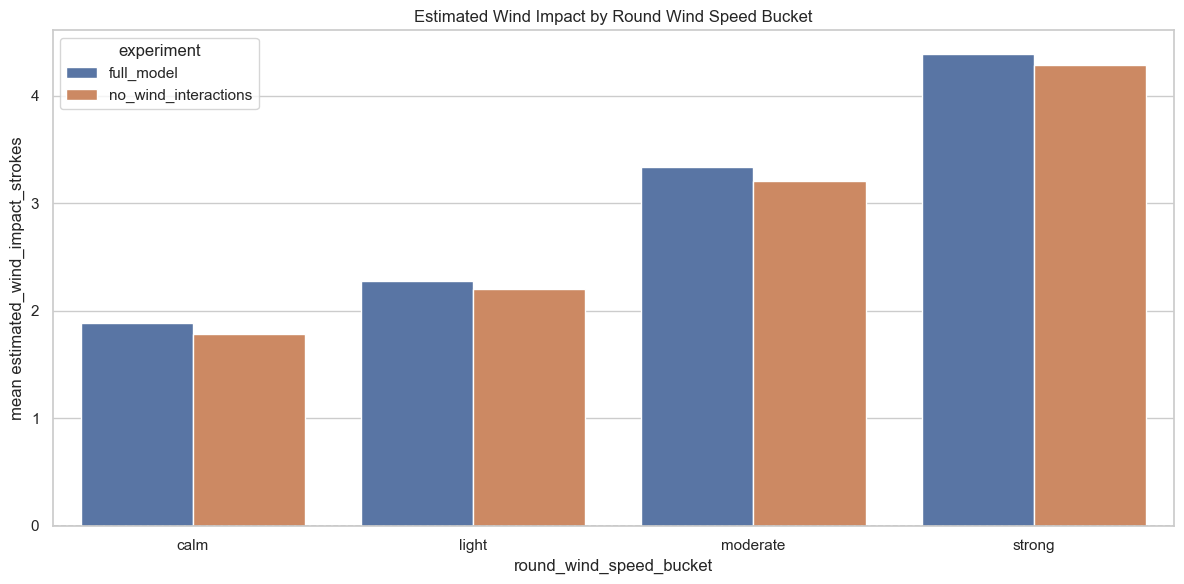

In [12]:
# -----------------------------------------------------------------------------
# Plot raw estimated wind impact by bucket
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.barplot(
    data=bucket_summary_df,
    x="round_wind_speed_bucket",
    y="estimated_wind_impact_mean",
    hue="experiment",
    order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Estimated Wind Impact by Round Wind Speed Bucket")
plt.xlabel("round_wind_speed_bucket")
plt.ylabel("mean estimated_wind_impact_strokes")
plt.tight_layout()
plt.show()


In [13]:
# -----------------------------------------------------------------------------
# Re-anchor wind impact relative to calm
# -----------------------------------------------------------------------------

relative_bucket_rows = []

for experiment_name, payload in experiment_scored_outputs.items():
    scored_df = payload["scored_df"]

    summary_df = summarize_round_group(
        scored_df[scored_df["round_wind_speed_bucket"].isin(WIND_SPEED_ORDER)].copy(),
        ["round_wind_speed_bucket"],
    ).sort_values("round_wind_speed_bucket").reset_index(drop=True)

    calm_value = float(
        summary_df.loc[
            summary_df["round_wind_speed_bucket"] == "calm",
            "estimated_wind_impact_mean"
        ].iloc[0]
    )

    summary_df["estimated_wind_impact_vs_calm"] = summary_df["estimated_wind_impact_mean"] - calm_value
    summary_df["experiment"] = experiment_name
    relative_bucket_rows.append(summary_df)

relative_bucket_df = pd.concat(relative_bucket_rows, ignore_index=True)
relative_bucket_df


,round_wind_speed_bucket,rows,actual_round_strokes_mean,predicted_round_strokes_mean,round_residual_mean,estimated_wind_impact_mean,round_wind_speed_mps_mean,round_wind_gust_mps_mean,estimated_wind_impact_vs_calm,experiment
0,calm,31957,62.082267,62.104824,-0.022558,1.886960,1.186441,3.230341,0.000000,full_model
1,light,43750,62.319269,62.344119,-0.024850,2.280998,3.185367,6.704665,0.394038,full_model
2,moderate,7635,64.466405,64.476598,-0.010193,3.341166,5.979139,12.121192,1.454206,full_model
3,strong,624,66.541667,66.640307,-0.098640,4.389765,8.911795,17.096795,2.502805,full_model
4,calm,31957,62.082267,62.104397,-0.022131,1.784318,1.186441,3.230341,0.000000,no_wind_interactions
5,light,43750,62.319269,62.348222,-0.028954,2.199464,3.185367,6.704665,0.415146,no_wind_interactions
6,moderate,7635,64.466405,64.463500,0.002905,3.209845,5.979139,12.121192,1.425527,no_wind_interactions
7,strong,624,66.541667,66.659570,-0.117903,4.290177,8.911795,17.096795,2.505859,no_wind_interactions


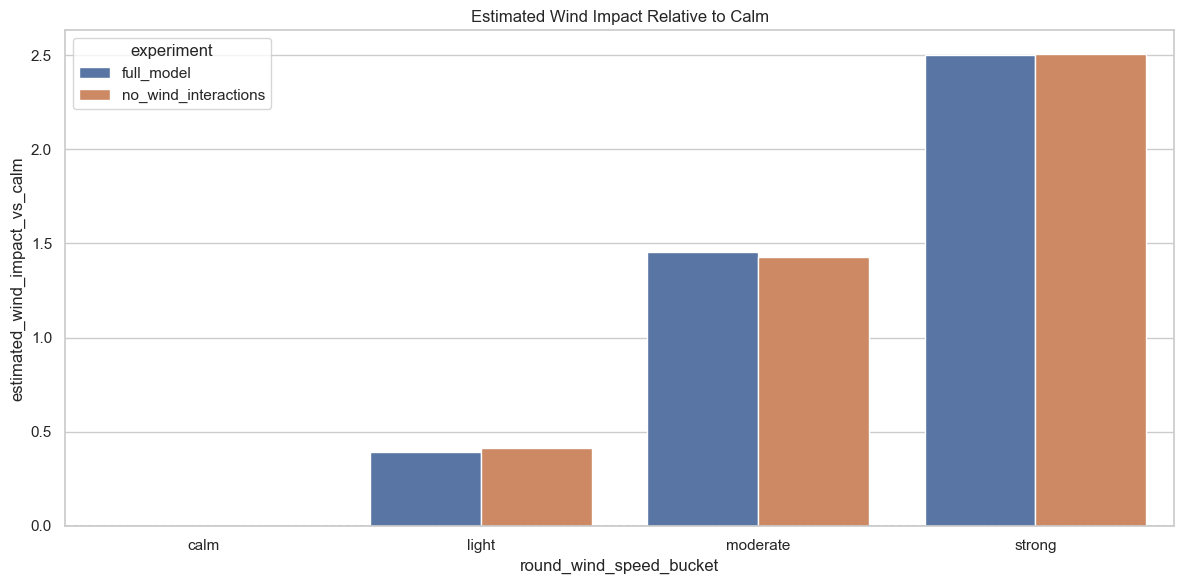

In [14]:
# -----------------------------------------------------------------------------
# Plot wind impact relative to calm
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.barplot(
    data=relative_bucket_df,
    x="round_wind_speed_bucket",
    y="estimated_wind_impact_vs_calm",
    hue="experiment",
    order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title("Estimated Wind Impact Relative to Calm")
plt.xlabel("round_wind_speed_bucket")
plt.ylabel("estimated_wind_impact_vs_calm")
plt.tight_layout()
plt.show()


In [15]:
# -----------------------------------------------------------------------------
# Feature importance for both models
# -----------------------------------------------------------------------------

feature_importance_frames = []

for experiment_name, payload in experiment_scored_outputs.items():
    model = payload["model"]
    train_pool = payload["train_pool"]
    feature_cols = payload["feature_cols"]

    fi_df = pd.DataFrame(
        {
            "experiment": experiment_name,
            "feature": feature_cols,
            "importance": model.get_feature_importance(train_pool),
        }
    ).sort_values("importance", ascending=False).reset_index(drop=True)

    feature_importance_frames.append(fi_df)

feature_importance_df = pd.concat(feature_importance_frames, ignore_index=True)
feature_importance_df.head(30)


,experiment,feature,importance
0,full_model,round_total_par,31.704632
1,full_model,player_rating,25.455298
2,full_model,round_length_over_par,7.368472
3,full_model,layout_id,5.981605
4,full_model,round_total_hole_length,5.513410
5,full_model,course_id,5.006876
6,full_model,hole_count,2.872836
7,full_model,round_avg_hole_par,2.615220
8,full_model,round_temp_c_mean,2.049560
9,full_model,round_avg_hole_length,1.835852


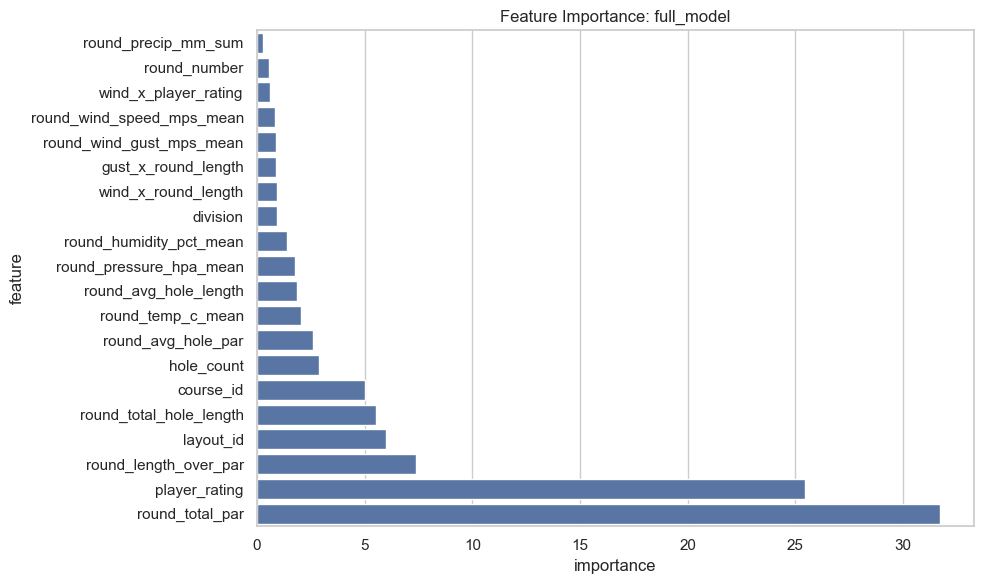

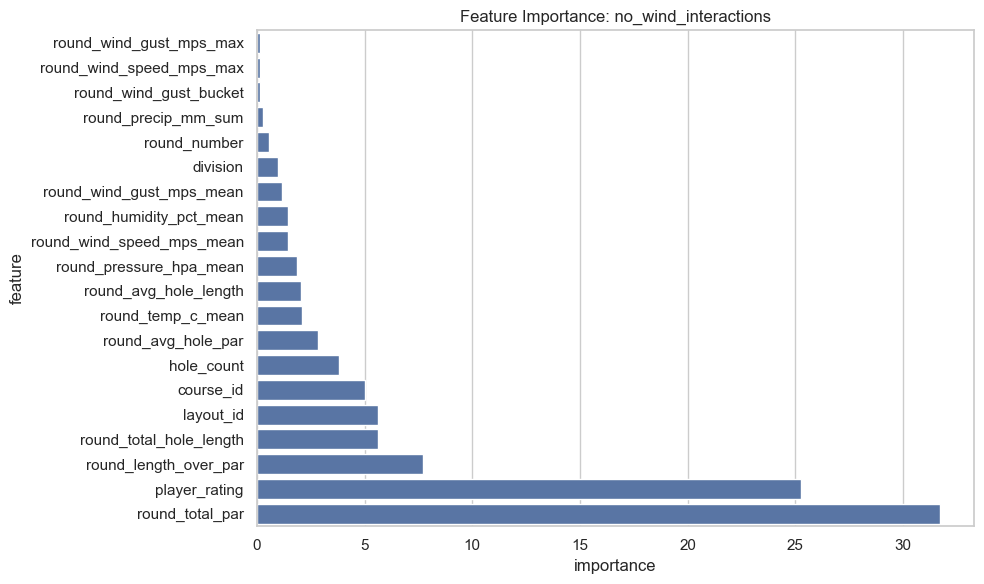

In [16]:
# -----------------------------------------------------------------------------
# Plot feature importance for each model
# -----------------------------------------------------------------------------

for experiment_name in feature_importance_df["experiment"].unique():
    plt.figure(figsize=(10, 6))
    plot_df = (
        feature_importance_df[feature_importance_df["experiment"] == experiment_name]
        .head(20)
        .iloc[::-1]
    )

    sns.barplot(data=plot_df, x="importance", y="feature")
    plt.title(f"Feature Importance: {experiment_name}")
    plt.xlabel("importance")
    plt.ylabel("feature")
    plt.tight_layout()
    plt.show()


In [17]:
# -----------------------------------------------------------------------------
# Choose the winning one-stage experiment
# -----------------------------------------------------------------------------

preferred_experiment = "no_wind_interactions"
preferred_payload = experiment_scored_outputs[preferred_experiment]

preferred_model = preferred_payload["model"]
preferred_scored_df = preferred_payload["scored_df"].copy()
preferred_feature_cols = preferred_payload["feature_cols"]
preferred_train_pool = preferred_payload["train_pool"]

print("Using experiment:", preferred_experiment)
print("Scored rows:", len(preferred_scored_df))
preferred_scored_df.head()

Using experiment: no_wind_interactions
Scored rows: 83969


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,round_wind_speed_bucket,round_wind_gust_bucket,predicted_round_strokes,round_residual_strokes,predicted_round_strokes_calm_counterfactual,estimated_wind_impact_strokes
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,light,high,83.094866,-1.094866,77.711009,5.383857
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,light,mild,105.765377,5.234623,104.858872,0.906505
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,light,high,45.010946,4.989054,43.329906,1.681040
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,light,high,58.514905,1.485095,55.748940,2.765965
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,calm,low,69.941372,3.058628,65.791405,4.149967


In [19]:
# -----------------------------------------------------------------------------
# Build player rating bins
# -----------------------------------------------------------------------------

PLAYER_RATING_BIN_EDGES = [0, 850, 900, 935, 970, 1000, 2000]
PLAYER_RATING_BIN_LABELS = [
    "<850",
    "850-899",
    "900-934",
    "935-969",
    "970-999",
    "1000+",
]

preferred_scored_df["player_rating_bin"] = pd.cut(
    preferred_scored_df["player_rating"],
    bins=PLAYER_RATING_BIN_EDGES,
    labels=PLAYER_RATING_BIN_LABELS,
    right=False,
    include_lowest=True,
)

preferred_scored_df["player_rating_bin"] = preferred_scored_df["player_rating_bin"].astype("string")
preferred_scored_df[["player_rating", "player_rating_bin"]].head()

,player_rating,player_rating_bin
405787,853.0,850-899
163523,744.0,<850
145680,1000.0,1000+
193881,896.0,850-899
21439,911.0,900-934


In [32]:
# -----------------------------------------------------------------------------
# Add subgroup helpers
# -----------------------------------------------------------------------------

PLAYER_RATING_BIN_EDGES = [0, 850, 900, 935, 970, 1000, 2000]
PLAYER_RATING_BIN_LABELS = [
    "<850",
    "850-899",
    "900-934",
    "935-969",
    "970-999",
    "1000+",
]

preferred_scored_df["player_rating_bin"] = pd.cut(
    preferred_scored_df["player_rating"],
    bins=PLAYER_RATING_BIN_EDGES,
    labels=PLAYER_RATING_BIN_LABELS,
    right=False,
    include_lowest=True,
)

preferred_scored_df["player_rating_bin"] = preferred_scored_df["player_rating_bin"].astype("string")
preferred_scored_df["division"] = preferred_scored_df["division"].astype("string")
preferred_scored_df["course_id"] = preferred_scored_df["course_id"].astype("string")
preferred_scored_df["round_wind_speed_bucket"] = preferred_scored_df["round_wind_speed_bucket"].astype("string")



In [33]:
# -----------------------------------------------------------------------------
# Continuous weather units
# -----------------------------------------------------------------------------

MPS_TO_MPH = 2.23694

preferred_scored_df["round_wind_speed_mph_mean"] = preferred_scored_df["round_wind_speed_mps_mean"] * MPS_TO_MPH
preferred_scored_df["round_wind_gust_mph_mean"] = preferred_scored_df["round_wind_gust_mps_mean"] * MPS_TO_MPH



In [34]:
# -----------------------------------------------------------------------------
# Relative-to-subgroup-calm helper
# -----------------------------------------------------------------------------

def summarize_relative_to_subgroup_calm(
    df: pd.DataFrame,
    subgroup_cols: list[str],
    min_rows: int = 30,
    calm_bucket_col: str = "round_wind_speed_bucket",
    calm_bucket_value: str = "calm",
) -> pd.DataFrame:
    overall_df = (
        df.groupby(subgroup_cols, dropna=False, as_index=False)
        .agg(
            rows=("actual_round_strokes", "size"),
            estimated_wind_impact_mean=("estimated_wind_impact_strokes", "mean"),
            estimated_wind_impact_median=("estimated_wind_impact_strokes", "median"),
            round_wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
            round_temp_c_mean=("round_temp_c_mean", "mean"),
            player_rating_mean=("player_rating", "mean"),
        )
    )

    calm_df = (
        df[df[calm_bucket_col] == calm_bucket_value]
        .groupby(subgroup_cols, dropna=False, as_index=False)
        .agg(
            calm_rows=("actual_round_strokes", "size"),
            subgroup_calm_impact_mean=("estimated_wind_impact_strokes", "mean"),
            subgroup_calm_wind_mph_mean=("round_wind_speed_mph_mean", "mean"),
        )
    )

    summary_df = overall_df.merge(calm_df, on=subgroup_cols, how="left")

    summary_df["estimated_wind_impact_vs_subgroup_calm"] = (
        summary_df["estimated_wind_impact_mean"] - summary_df["subgroup_calm_impact_mean"]
    )

    # Convert to a normalized rate: expected strokes added per 5 mph above subgroup calm baseline.
    summary_df["wind_mph_above_subgroup_calm"] = (
        summary_df["round_wind_speed_mph_mean"] - summary_df["subgroup_calm_wind_mph_mean"]
    )

    summary_df["expected_strokes_added_per_5_mph_vs_subgroup_calm"] = np.where(
        summary_df["wind_mph_above_subgroup_calm"].abs() > 1e-9,
        summary_df["estimated_wind_impact_vs_subgroup_calm"] / summary_df["wind_mph_above_subgroup_calm"] * 5.0,
        np.nan,
    )

    summary_df = summary_df[
        (summary_df["rows"] >= min_rows) &
        (summary_df["calm_rows"].fillna(0) >= max(10, min_rows // 3))
    ].copy()

    summary_df = summary_df.sort_values(
        ["estimated_wind_impact_vs_subgroup_calm", "rows"],
        ascending=[False, False],
    ).reset_index(drop=True)

    return summary_df


In [35]:
# -----------------------------------------------------------------------------
# Subgroup summaries relative to each subgroup's calm rows
# -----------------------------------------------------------------------------

wind_by_division_rel_calm_df = summarize_relative_to_subgroup_calm(
    preferred_scored_df[preferred_scored_df["division"].notna()].copy(),
    subgroup_cols=["division"],
    min_rows=50,
)

wind_by_rating_bin_rel_calm_df = summarize_relative_to_subgroup_calm(
    preferred_scored_df[preferred_scored_df["player_rating_bin"].notna()].copy(),
    subgroup_cols=["player_rating_bin"],
    min_rows=50,
)

wind_by_course_rel_calm_df = summarize_relative_to_subgroup_calm(
    preferred_scored_df[preferred_scored_df["course_id"].notna()].copy(),
    subgroup_cols=["course_id"],
    min_rows=100,
)

wind_by_rating_bin_rel_calm_df["player_rating_bin"] = pd.Categorical(
    wind_by_rating_bin_rel_calm_df["player_rating_bin"],
    categories=PLAYER_RATING_BIN_LABELS,
    ordered=True,
)

wind_by_rating_bin_rel_calm_df = wind_by_rating_bin_rel_calm_df.sort_values(
    "player_rating_bin"
).reset_index(drop=True)

wind_by_division_rel_calm_df, wind_by_rating_bin_rel_calm_df.head(), wind_by_course_rel_calm_df.head()



(   division   rows  estimated_wind_impact_mean  estimated_wind_impact_median  \
 0      MJ12     75                    0.462861                      0.323137   
 1      MJ18    462                    1.352114                      1.356298   
 2      MA55    157                    1.402369                      1.255423   
 3       FA2    658                    0.277314                      0.213544   
 4      FP40    247                    0.697365                      0.505049   
 5       FA4    354                   -0.669208                     -0.601207   
 6       MA3  12313                    1.929617                      1.787582   
 7      MP40   4578                    3.020312                      2.857465   
 8      MP70     94                    1.432458                      1.655905   
 9      MA70    301                    0.866618                      0.792718   
 10      MPO  14029                    2.688587                      2.538002   
 11      MC2    114         

In [36]:
# -----------------------------------------------------------------------------
# Subgroup + wind bucket summaries relative to subgroup calm
# -----------------------------------------------------------------------------

def summarize_bucket_relative_to_subgroup_calm(
    df: pd.DataFrame,
    subgroup_cols: list[str],
    bucket_col: str = "round_wind_speed_bucket",
    bucket_order: list[str] | None = None,
    min_rows: int = 30,
) -> pd.DataFrame:
    group_cols = subgroup_cols + [bucket_col]

    bucket_df = (
        df.groupby(group_cols, dropna=False, as_index=False)
        .agg(
            rows=("actual_round_strokes", "size"),
            estimated_wind_impact_mean=("estimated_wind_impact_strokes", "mean"),
            round_wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
            round_temp_c_mean=("round_temp_c_mean", "mean"),
        )
    )

    calm_df = (
        df[df[bucket_col] == "calm"]
        .groupby(subgroup_cols, dropna=False, as_index=False)
        .agg(
            calm_rows=("actual_round_strokes", "size"),
            subgroup_calm_impact_mean=("estimated_wind_impact_strokes", "mean"),
            subgroup_calm_wind_mph_mean=("round_wind_speed_mph_mean", "mean"),
        )
    )

    summary_df = bucket_df.merge(calm_df, on=subgroup_cols, how="left")

    summary_df["estimated_wind_impact_vs_subgroup_calm"] = (
        summary_df["estimated_wind_impact_mean"] - summary_df["subgroup_calm_impact_mean"]
    )

    summary_df["wind_mph_above_subgroup_calm"] = (
        summary_df["round_wind_speed_mph_mean"] - summary_df["subgroup_calm_wind_mph_mean"]
    )

    summary_df["expected_strokes_added_per_5_mph_vs_subgroup_calm"] = np.where(
        summary_df["wind_mph_above_subgroup_calm"].abs() > 1e-9,
        summary_df["estimated_wind_impact_vs_subgroup_calm"] / summary_df["wind_mph_above_subgroup_calm"] * 5.0,
        np.nan,
    )

    summary_df = summary_df[
        (summary_df["rows"] >= min_rows) &
        (summary_df["calm_rows"].fillna(0) >= max(10, min_rows // 3))
    ].copy()

    if bucket_order is not None:
        summary_df[bucket_col] = pd.Categorical(
            summary_df[bucket_col],
            categories=bucket_order,
            ordered=True,
        )

    return summary_df.sort_values(subgroup_cols + [bucket_col]).reset_index(drop=True)


In [37]:
# -----------------------------------------------------------------------------
# Division and rating-bin bucket summaries
# -----------------------------------------------------------------------------

wind_by_division_bucket_rel_calm_df = summarize_bucket_relative_to_subgroup_calm(
    preferred_scored_df[
        preferred_scored_df["division"].notna() &
        preferred_scored_df["round_wind_speed_bucket"].isin(WIND_SPEED_ORDER)
    ].copy(),
    subgroup_cols=["division"],
    bucket_col="round_wind_speed_bucket",
    bucket_order=WIND_SPEED_ORDER,
    min_rows=30,
)

wind_by_rating_bucket_rel_calm_df = summarize_bucket_relative_to_subgroup_calm(
    preferred_scored_df[
        preferred_scored_df["player_rating_bin"].notna() &
        preferred_scored_df["round_wind_speed_bucket"].isin(WIND_SPEED_ORDER)
    ].copy(),
    subgroup_cols=["player_rating_bin"],
    bucket_col="round_wind_speed_bucket",
    bucket_order=WIND_SPEED_ORDER,
    min_rows=30,
)

wind_by_rating_bucket_rel_calm_df["player_rating_bin"] = pd.Categorical(
    wind_by_rating_bucket_rel_calm_df["player_rating_bin"],
    categories=PLAYER_RATING_BIN_LABELS,
    ordered=True,
)

wind_by_division_bucket_rel_calm_df.head(), wind_by_rating_bucket_rel_calm_df.head()


(  division round_wind_speed_bucket  rows  estimated_wind_impact_mean  \
 0      FA1                    calm   352                    0.603938   
 1      FA1                   light   493                    0.715132   
 2      FA1                moderate    75                    2.438538   
 3      FA2                    calm   238                   -0.220449   
 4      FA2                   light   359                    0.396783   
 
    round_wind_speed_mph_mean  round_temp_c_mean  calm_rows  \
 0                   2.648995          15.511648      352.0   
 1                   6.977801          15.607708      352.0   
 2                  13.138294          15.545333      352.0   
 3                   2.683388          15.594958      238.0   
 4                   7.014334          15.272145      238.0   
 
    subgroup_calm_impact_mean  subgroup_calm_wind_mph_mean  \
 0                   0.603938                     2.648995   
 1                   0.603938                     2.6489

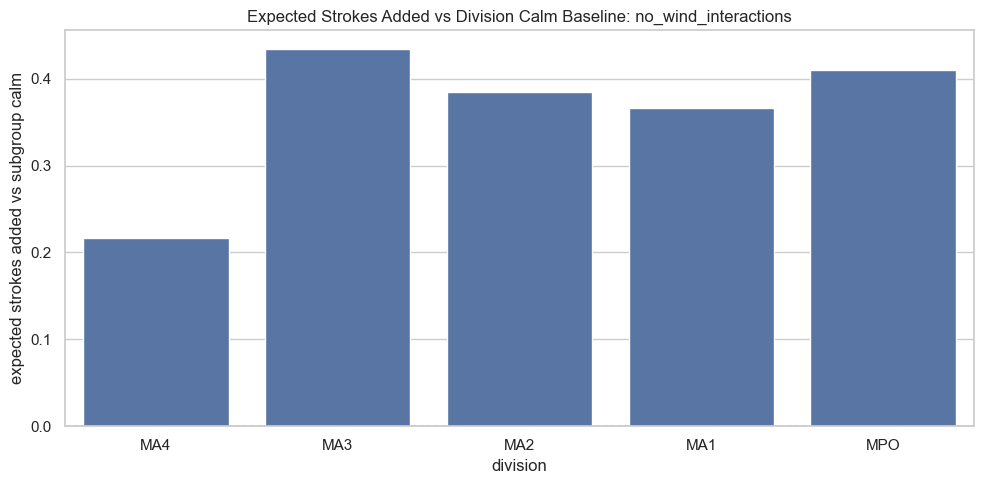

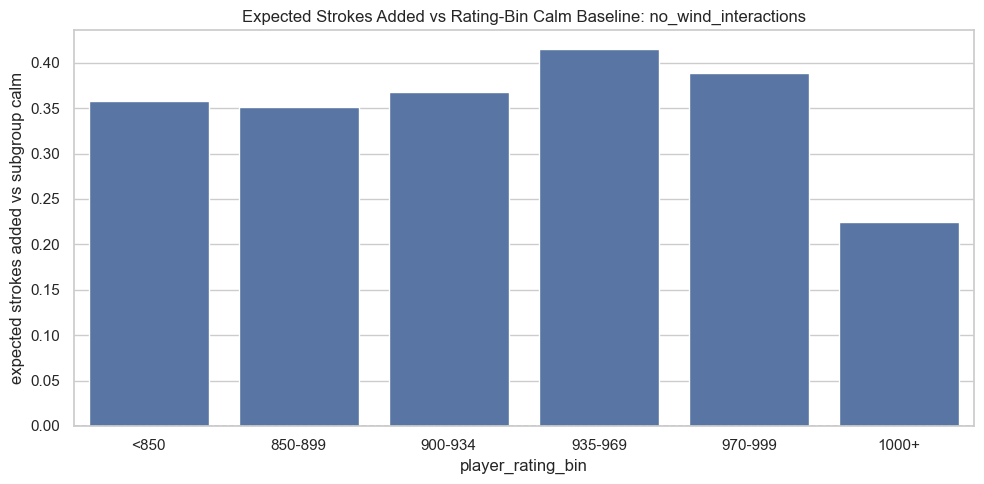

In [38]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added vs subgroup calm baseline
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=wind_by_division_rel_calm_df,
    x="division",
    y="estimated_wind_impact_vs_subgroup_calm",
    order=DIVISION_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added vs Division Calm Baseline: {preferred_experiment}")
plt.xlabel("division")
plt.ylabel("expected strokes added vs subgroup calm")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=wind_by_rating_bin_rel_calm_df,
    x="player_rating_bin",
    y="estimated_wind_impact_vs_subgroup_calm",
    order=PLAYER_RATING_BIN_LABELS,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added vs Rating-Bin Calm Baseline: {preferred_experiment}")
plt.xlabel("player_rating_bin")
plt.ylabel("expected strokes added vs subgroup calm")
plt.tight_layout()
plt.show()


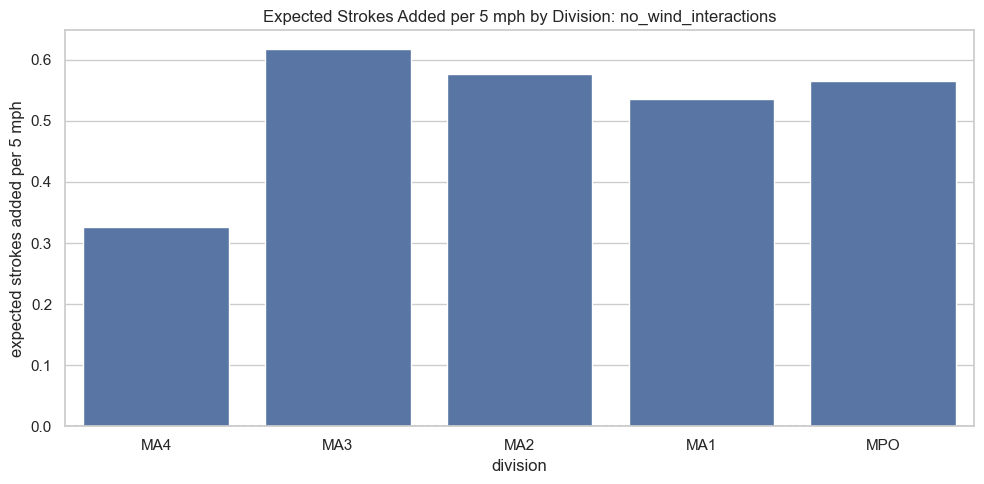

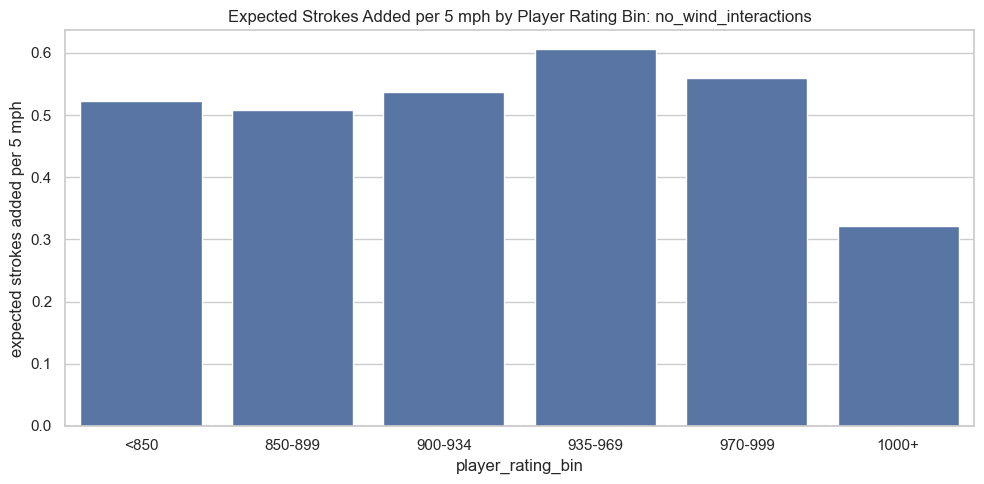

In [39]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added per 5 mph by subgroup
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=wind_by_division_rel_calm_df,
    x="division",
    y="expected_strokes_added_per_5_mph_vs_subgroup_calm",
    order=DIVISION_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added per 5 mph by Division: {preferred_experiment}")
plt.xlabel("division")
plt.ylabel("expected strokes added per 5 mph")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(
    data=wind_by_rating_bin_rel_calm_df,
    x="player_rating_bin",
    y="expected_strokes_added_per_5_mph_vs_subgroup_calm",
    order=PLAYER_RATING_BIN_LABELS,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added per 5 mph by Player Rating Bin: {preferred_experiment}")
plt.xlabel("player_rating_bin")
plt.ylabel("expected strokes added per 5 mph")
plt.tight_layout()
plt.show()



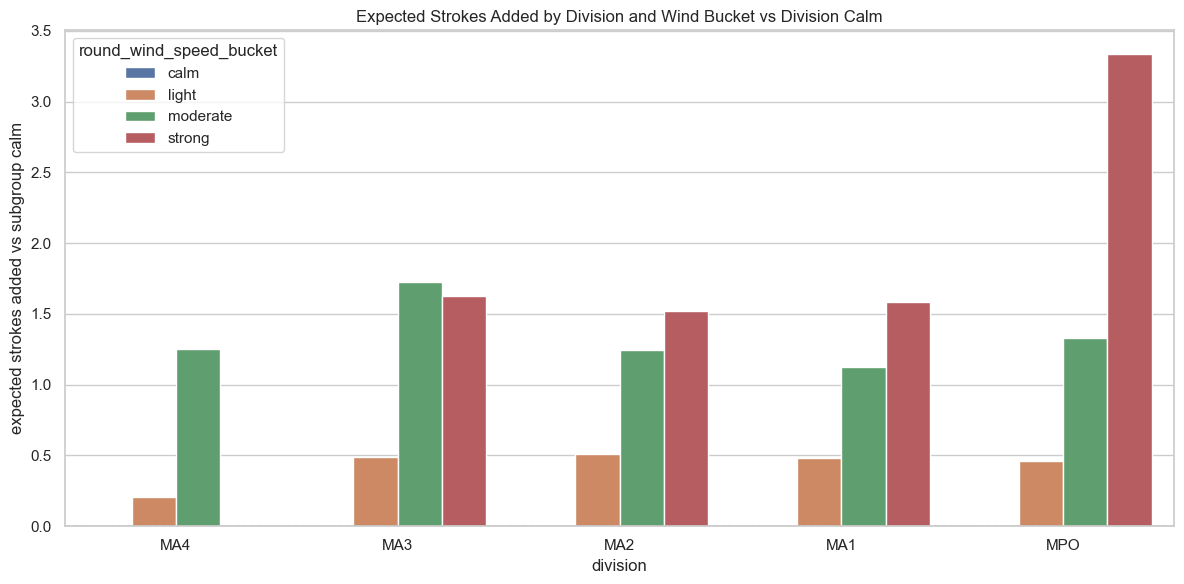

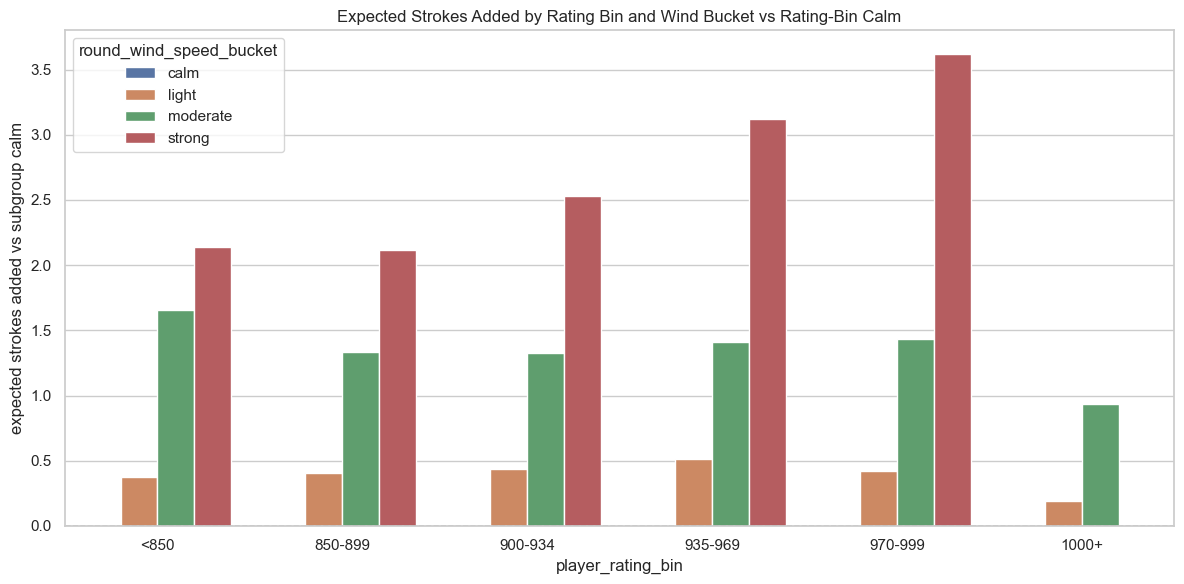

In [40]:
# -----------------------------------------------------------------------------
# Plot: subgroup curves by wind bucket, relative to subgroup calm
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 6))
sns.barplot(
    data=wind_by_division_bucket_rel_calm_df,
    x="division",
    y="estimated_wind_impact_vs_subgroup_calm",
    hue="round_wind_speed_bucket",
    order=DIVISION_ORDER,
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added by Division and Wind Bucket vs Division Calm")
plt.xlabel("division")
plt.ylabel("expected strokes added vs subgroup calm")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=wind_by_rating_bucket_rel_calm_df,
    x="player_rating_bin",
    y="estimated_wind_impact_vs_subgroup_calm",
    hue="round_wind_speed_bucket",
    order=PLAYER_RATING_BIN_LABELS,
    hue_order=WIND_SPEED_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added by Rating Bin and Wind Bucket vs Rating-Bin Calm")
plt.xlabel("player_rating_bin")
plt.ylabel("expected strokes added vs subgroup calm")
plt.tight_layout()
plt.show()



In [51]:
# -----------------------------------------------------------------------------
# Wind-speed curve prep
# -----------------------------------------------------------------------------

WIND_MPH_BIN_WIDTH = 3
WIND_MPH_MAX = 35

wind_bin_edges = list(range(0, WIND_MPH_MAX + WIND_MPH_BIN_WIDTH, WIND_MPH_BIN_WIDTH))
wind_bin_labels = [f"{left}-{left + WIND_MPH_BIN_WIDTH - 1}" for left in wind_bin_edges[:-1]]

preferred_scored_df["wind_speed_mph_bin"] = pd.cut(
    preferred_scored_df["round_wind_speed_mph_mean"],
    bins=wind_bin_edges,
    labels=wind_bin_labels,
    right=False,
    include_lowest=True,
)

preferred_scored_df["wind_speed_mph_bin"] = preferred_scored_df["wind_speed_mph_bin"].astype("string")
preferred_scored_df[["round_wind_speed_mph_mean", "wind_speed_mph_bin"]].head()



,round_wind_speed_mph_mean,wind_speed_mph_bin
405787,9.283301,9-11
163523,6.487126,6-8
145680,6.352910,6-8
193881,8.030615,6-8
21439,3.288302,3-5


In [52]:
# -----------------------------------------------------------------------------
# Expected strokes added vs wind speed
# -----------------------------------------------------------------------------

wind_speed_curve_df = (
    preferred_scored_df[preferred_scored_df["wind_speed_mph_bin"].notna()]
    .groupby("wind_speed_mph_bin", dropna=False, as_index=False)
    .agg(
        rows=("actual_round_strokes", "size"),
        estimated_wind_impact_mean=("estimated_wind_impact_strokes", "mean"),
        wind_speed_mph_mean=("round_wind_speed_mph_mean", "mean"),
    )
)

calm_curve_mean = (
    preferred_scored_df.loc[
        preferred_scored_df["round_wind_speed_bucket"] == "calm",
        "estimated_wind_impact_strokes"
    ].mean()
)

wind_speed_curve_df["expected_strokes_added_vs_calm"] = (
    wind_speed_curve_df["estimated_wind_impact_mean"] - calm_curve_mean
)

wind_speed_curve_df = wind_speed_curve_df[wind_speed_curve_df["rows"] >= 30].copy()
wind_speed_curve_df = wind_speed_curve_df.sort_values("wind_speed_mph_mean").reset_index(drop=True)

wind_speed_curve_df



,wind_speed_mph_bin,rows,estimated_wind_impact_mean,wind_speed_mph_mean,expected_strokes_added_vs_calm
0,0-2,17966,1.736969,1.811654,-0.047349
1,3-5,28940,1.894239,4.503865,0.109921
2,6-8,20609,2.222463,7.373051,0.438145
3,9-11,10164,2.660373,10.281239,0.876055
4,12-14,4140,3.345226,13.220061,1.560908
5,15-17,1551,3.318789,16.184773,1.534471
6,18-20,451,4.222571,19.130896,2.438253
7,21-23,108,4.508316,22.140321,2.723998
8,24-26,37,4.753191,24.817338,2.968873


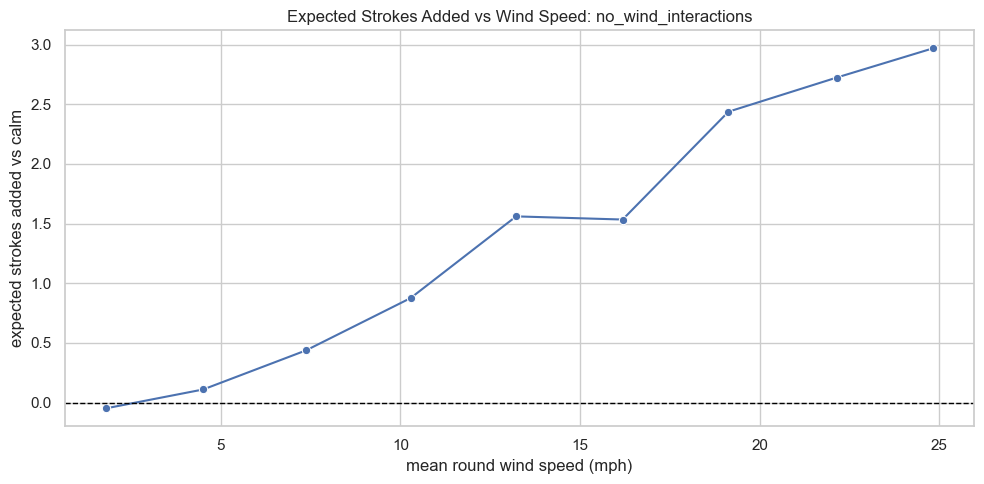

In [53]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added vs wind speed
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=wind_speed_curve_df,
    x="wind_speed_mph_mean",
    y="expected_strokes_added_vs_calm",
    marker="o",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added vs Wind Speed: {preferred_experiment}")
plt.xlabel("mean round wind speed (mph)")
plt.ylabel("expected strokes added vs calm")
plt.tight_layout()
plt.show()



In [44]:
# -----------------------------------------------------------------------------
# Add strokes-per-5-mph slope at the wind-speed bin level
# -----------------------------------------------------------------------------

wind_speed_curve_df["expected_strokes_added_per_5_mph"] = np.where(
    wind_speed_curve_df["wind_speed_mph_mean"].abs() > 1e-9,
    wind_speed_curve_df["expected_strokes_added_vs_calm"] / wind_speed_curve_df["wind_speed_mph_mean"] * 5.0,
    np.nan,
)

wind_speed_curve_df


,wind_speed_mph_bin,rows,estimated_wind_impact_mean,wind_speed_mph_mean,expected_strokes_added_vs_calm,expected_strokes_added_per_5_mph
0,0-4,37314,1.785401,2.952879,0.001083,0.001833
1,5-9,34551,2.222139,7.114699,0.437821,0.307687
2,10-14,9954,2.945561,11.861270,1.161243,0.489510
3,15-19,1914,3.442464,16.679345,1.658146,0.497066
4,20-24,221,4.883312,21.763503,3.098994,0.711970


In [48]:
# -----------------------------------------------------------------------------
# Temperature curve prep
# -----------------------------------------------------------------------------

TEMP_C_BIN_WIDTH = 3
TEMP_C_MIN = int(np.floor(preferred_scored_df["round_temp_c_mean"].min() / 5.0) * 5)
TEMP_C_MAX = int(np.ceil(preferred_scored_df["round_temp_c_mean"].max() / 5.0) * 5)

temp_bin_edges = list(range(TEMP_C_MIN, TEMP_C_MAX + TEMP_C_BIN_WIDTH, TEMP_C_BIN_WIDTH))
temp_bin_labels = [f"{left} to {left + TEMP_C_BIN_WIDTH - 1}" for left in temp_bin_edges[:-1]]

preferred_scored_df["temp_c_bin"] = pd.cut(
    preferred_scored_df["round_temp_c_mean"],
    bins=temp_bin_edges,
    labels=temp_bin_labels,
    right=False,
    include_lowest=True,
)

preferred_scored_df["temp_c_bin"] = preferred_scored_df["temp_c_bin"].astype("string")
preferred_scored_df[["round_temp_c_mean", "temp_c_bin"]].head()


,round_temp_c_mean,temp_c_bin
405787,15.4,14 to 16
163523,18.4,17 to 19
145680,26.1,26 to 28
193881,-1.1,-4 to -2
21439,15.8,14 to 16


In [49]:
# -----------------------------------------------------------------------------
# Expected strokes added vs temperature
# -----------------------------------------------------------------------------

temp_curve_df = (
    preferred_scored_df[preferred_scored_df["temp_c_bin"].notna()]
    .groupby("temp_c_bin", dropna=False, as_index=False)
    .agg(
        rows=("actual_round_strokes", "size"),
        estimated_wind_impact_mean=("estimated_wind_impact_strokes", "mean"),
        temp_c_mean=("round_temp_c_mean", "mean"),
    )
)

overall_temp_reference = preferred_scored_df["estimated_wind_impact_strokes"].mean()

temp_curve_df["expected_strokes_added_vs_overall_mean"] = (
    temp_curve_df["estimated_wind_impact_mean"] - overall_temp_reference
)

temp_curve_df = temp_curve_df[temp_curve_df["rows"] >= 30].copy()
temp_curve_df = temp_curve_df.sort_values("temp_c_mean").reset_index(drop=True)

temp_curve_df


,temp_c_bin,rows,estimated_wind_impact_mean,temp_c_mean,expected_strokes_added_vs_overall_mean
0,-19 to -17,49,3.958401,-17.467347,1.809500
1,-16 to -14,136,2.882983,-14.222794,0.734081
2,-13 to -11,150,2.832434,-11.388000,0.683532
3,-10 to -8,234,3.932090,-8.208974,1.783188
4,-7 to -5,424,3.452619,-5.213679,1.303717
5,-4 to -2,1500,3.017290,-2.435400,0.868388
6,-1 to 1,2596,2.750083,0.453737,0.601181
7,2 to 4,4313,2.139412,3.529701,-0.009490
8,5 to 7,6025,1.881639,6.473859,-0.267263
9,8 to 10,7937,1.795681,9.526471,-0.353221


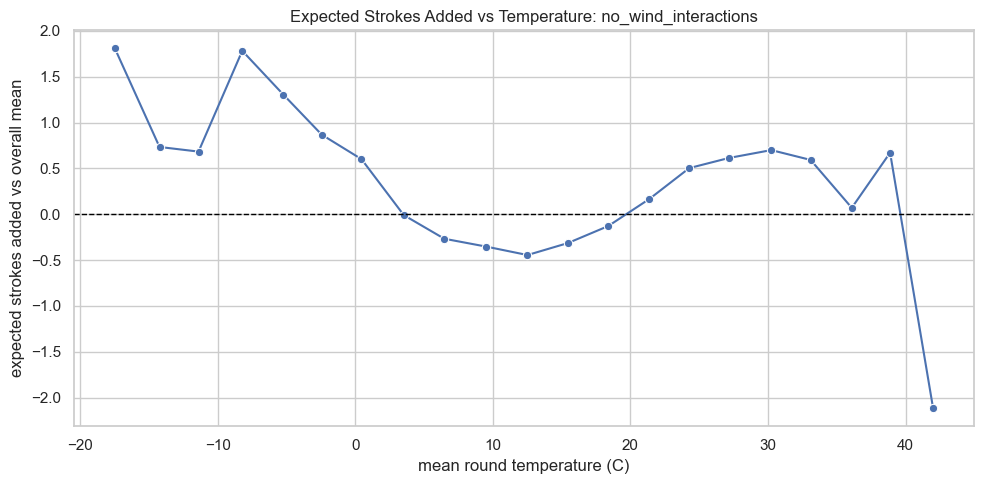

In [50]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added vs temperature
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.lineplot(
    data=temp_curve_df,
    x="temp_c_mean",
    y="expected_strokes_added_vs_overall_mean",
    marker="o",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added vs Temperature: {preferred_experiment}")
plt.xlabel("mean round temperature (C)")
plt.ylabel("expected strokes added vs overall mean")
plt.tight_layout()
plt.show()


In [55]:
# -----------------------------------------------------------------------------
# Regression-ready analysis frame
# -----------------------------------------------------------------------------

sensitivity_df = preferred_scored_df.copy()

required_cols = [
    "estimated_wind_impact_strokes",
    "round_wind_speed_mph_mean",
    "round_temp_c_mean",
    "division",
    "player_rating_bin",
]

sensitivity_df = sensitivity_df.dropna(subset=required_cols).copy()

sensitivity_df["division"] = sensitivity_df["division"].astype("string")
sensitivity_df["player_rating_bin"] = sensitivity_df["player_rating_bin"].astype("string")

print("Sensitivity rows:", len(sensitivity_df))
sensitivity_df[
    [
        "estimated_wind_impact_strokes",
        "round_wind_speed_mph_mean",
        "round_temp_c_mean",
        "division",
        "player_rating_bin",
    ]
].head()


Sensitivity rows: 83969


,estimated_wind_impact_strokes,round_wind_speed_mph_mean,round_temp_c_mean,division,player_rating_bin
405787,5.383857,9.283301,15.4,MA3,850-899
163523,0.906505,6.487126,18.4,MA40,<850
145680,1.681040,6.352910,26.1,MPO,1000+
193881,2.765965,8.030615,-1.1,MP50,850-899
21439,4.149967,3.288302,15.8,MA2,900-934


In [56]:
# -----------------------------------------------------------------------------
# Overall wind sensitivity regression
# -----------------------------------------------------------------------------

overall_wind_model = smf.ols(
    formula="estimated_wind_impact_strokes ~ round_wind_speed_mph_mean",
    data=sensitivity_df,
).fit()

print(overall_wind_model.summary())


                                  OLS Regression Results                                 
Dep. Variable:     estimated_wind_impact_strokes   R-squared:                       0.060
Model:                                       OLS   Adj. R-squared:                  0.060
Method:                            Least Squares   F-statistic:                     5358.
Date:                           Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                                   09:34:40   Log-Likelihood:            -1.6991e+05
No. Observations:                          83969   AIC:                         3.398e+05
Df Residuals:                              83967   BIC:                         3.398e+05
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------

In [57]:
# -----------------------------------------------------------------------------
# Convert overall slope into expected strokes added per 5 mph
# -----------------------------------------------------------------------------

overall_wind_slope_per_mph = overall_wind_model.params["round_wind_speed_mph_mean"]
overall_wind_slope_per_5mph = overall_wind_slope_per_mph * 5.0

overall_wind_slope_df = pd.DataFrame(
    [
        {
            "model": "overall_wind_sensitivity",
            "slope_per_mph": overall_wind_slope_per_mph,
            "slope_per_5mph": overall_wind_slope_per_5mph,
            "intercept": overall_wind_model.params["Intercept"],
            "r_squared": overall_wind_model.rsquared,
        }
    ]
)

overall_wind_slope_df


,model,slope_per_mph,slope_per_5mph,intercept,r_squared
0,overall_wind_sensitivity,0.124386,0.62193,1.391652,0.059988


In [58]:
# -----------------------------------------------------------------------------
# Division-specific wind sensitivity regression
# -----------------------------------------------------------------------------

division_wind_model = smf.ols(
    formula="estimated_wind_impact_strokes ~ round_wind_speed_mph_mean * C(division)",
    data=sensitivity_df,
).fit()

print(division_wind_model.summary())


                                  OLS Regression Results                                 
Dep. Variable:     estimated_wind_impact_strokes   R-squared:                       0.207
Model:                                       OLS   Adj. R-squared:                  0.206
Method:                            Least Squares   F-statistic:                     178.2
Date:                           Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                                   09:35:19   Log-Likelihood:            -1.6275e+05
No. Observations:                          83969   AIC:                         3.257e+05
Df Residuals:                              83845   BIC:                         3.269e+05
Df Model:                                    123                                         
Covariance Type:                       nonrobust                                         
                                                           coef    std err          t      P>|t|    

In [59]:
# -----------------------------------------------------------------------------
# Extract division-specific slopes per 5 mph
# -----------------------------------------------------------------------------

base_division = sorted(sensitivity_df["division"].dropna().unique())[0]

division_rows = []
base_slope_per_mph = division_wind_model.params["round_wind_speed_mph_mean"]

for division in sorted(sensitivity_df["division"].dropna().unique()):
    interaction_term = f"round_wind_speed_mph_mean:C(division)[T.{division}]"

    slope_per_mph = base_slope_per_mph
    if division != base_division and interaction_term in division_wind_model.params.index:
        slope_per_mph += division_wind_model.params[interaction_term]

    division_rows.append(
        {
            "division": division,
            "slope_per_mph": slope_per_mph,
            "slope_per_5mph": slope_per_mph * 5.0,
        }
    )

division_wind_slopes_df = pd.DataFrame(division_rows)

division_wind_slopes_df["division"] = pd.Categorical(
    division_wind_slopes_df["division"],
    categories=DIVISION_ORDER,
    ordered=True,
)

division_wind_slopes_df = division_wind_slopes_df.sort_values("division").reset_index(drop=True)
division_wind_slopes_df


C:\Users\ryanc\AppData\Local\Temp\ipykernel_23896\3412355840.py:27: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  division_wind_slopes_df["division"] = pd.Categorical(


,division,slope_per_mph,slope_per_5mph
0,MA4,0.096130,0.480648
1,MA3,0.139864,0.699321
2,MA2,0.112339,0.561694
3,MA1,0.099191,0.495955
4,MPO,0.130838,0.654189
5,NaN,0.124030,0.620151
6,NaN,0.160024,0.800120
7,NaN,0.137001,0.685005
8,NaN,0.124155,0.620777
9,NaN,0.105132,0.525661


In [60]:
# -----------------------------------------------------------------------------
# Player-rating-bin-specific wind sensitivity regression
# -----------------------------------------------------------------------------

rating_wind_model = smf.ols(
    formula="estimated_wind_impact_strokes ~ round_wind_speed_mph_mean * C(player_rating_bin)",
    data=sensitivity_df,
).fit()

print(rating_wind_model.summary())


                                  OLS Regression Results                                 
Dep. Variable:     estimated_wind_impact_strokes   R-squared:                       0.174
Model:                                       OLS   Adj. R-squared:                  0.174
Method:                            Least Squares   F-statistic:                     1606.
Date:                           Tue, 31 Mar 2026   Prob (F-statistic):               0.00
Time:                                   09:35:55   Log-Likelihood:            -1.6449e+05
No. Observations:                          83969   AIC:                         3.290e+05
Df Residuals:                              83957   BIC:                         3.291e+05
Df Model:                                     11                                         
Covariance Type:                       nonrobust                                         
                                                                coef    std err          t      P>|t

In [61]:
# -----------------------------------------------------------------------------
# Extract player-rating-bin-specific slopes per 5 mph
# -----------------------------------------------------------------------------

rating_rows = []
base_rating_bin = PLAYER_RATING_BIN_LABELS[0]
base_slope_per_mph = rating_wind_model.params["round_wind_speed_mph_mean"]

for rating_bin in PLAYER_RATING_BIN_LABELS:
    interaction_term = f"round_wind_speed_mph_mean:C(player_rating_bin)[T.{rating_bin}]"

    slope_per_mph = base_slope_per_mph
    if rating_bin != base_rating_bin and interaction_term in rating_wind_model.params.index:
        slope_per_mph += rating_wind_model.params[interaction_term]

    rating_rows.append(
        {
            "player_rating_bin": rating_bin,
            "slope_per_mph": slope_per_mph,
            "slope_per_5mph": slope_per_mph * 5.0,
        }
    )

rating_wind_slopes_df = pd.DataFrame(rating_rows)
rating_wind_slopes_df["player_rating_bin"] = pd.Categorical(
    rating_wind_slopes_df["player_rating_bin"],
    categories=PLAYER_RATING_BIN_LABELS,
    ordered=True,
)
rating_wind_slopes_df = rating_wind_slopes_df.sort_values("player_rating_bin").reset_index(drop=True)
rating_wind_slopes_df


,player_rating_bin,slope_per_mph,slope_per_5mph
0,<850,0.099100,0.495499
1,850-899,0.117316,0.586580
2,900-934,0.121011,0.605054
3,935-969,0.131861,0.659305
4,970-999,0.134754,0.673768
5,1000+,0.099100,0.495499


In [62]:
# -----------------------------------------------------------------------------
# Temperature sensitivity regression
# -----------------------------------------------------------------------------

overall_temp_model = smf.ols(
    formula="estimated_wind_impact_strokes ~ round_temp_c_mean",
    data=sensitivity_df,
).fit()

print(overall_temp_model.summary())


                                  OLS Regression Results                                 
Dep. Variable:     estimated_wind_impact_strokes   R-squared:                       0.003
Model:                                       OLS   Adj. R-squared:                  0.003
Method:                            Least Squares   F-statistic:                     231.1
Date:                           Tue, 31 Mar 2026   Prob (F-statistic):           4.06e-52
Time:                                   09:36:25   Log-Likelihood:            -1.7239e+05
No. Observations:                          83969   AIC:                         3.448e+05
Df Residuals:                              83967   BIC:                         3.448e+05
Df Model:                                      1                                         
Covariance Type:                       nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
--------------

In [63]:
# -----------------------------------------------------------------------------
# Convert temperature slope into expected strokes added per 5 C
# -----------------------------------------------------------------------------

overall_temp_slope_per_c = overall_temp_model.params["round_temp_c_mean"]
overall_temp_slope_per_5c = overall_temp_slope_per_c * 5.0

overall_temp_slope_df = pd.DataFrame(
    [
        {
            "model": "overall_temperature_sensitivity",
            "slope_per_c": overall_temp_slope_per_c,
            "slope_per_5c": overall_temp_slope_per_5c,
            "intercept": overall_temp_model.params["Intercept"],
            "r_squared": overall_temp_model.rsquared,
        }
    ]
)

overall_temp_slope_df


,model,slope_per_c,slope_per_5c,intercept,r_squared
0,overall_temperature_sensitivity,0.012061,0.060307,1.963463,0.002745


In [64]:
# -----------------------------------------------------------------------------
# Build fitted wind-speed line
# -----------------------------------------------------------------------------

wind_line_x = np.linspace(
    sensitivity_df["round_wind_speed_mph_mean"].min(),
    sensitivity_df["round_wind_speed_mph_mean"].max(),
    100,
)

wind_line_df = pd.DataFrame(
    {
        "round_wind_speed_mph_mean": wind_line_x,
    }
)

wind_line_df["predicted_expected_strokes_added"] = overall_wind_model.predict(wind_line_df)
wind_line_df.head()


,round_wind_speed_mph_mean,predicted_expected_strokes_added
0,0.000000,1.391652
1,0.286961,1.427346
2,0.573922,1.463040
3,0.860883,1.498734
4,1.147844,1.534428


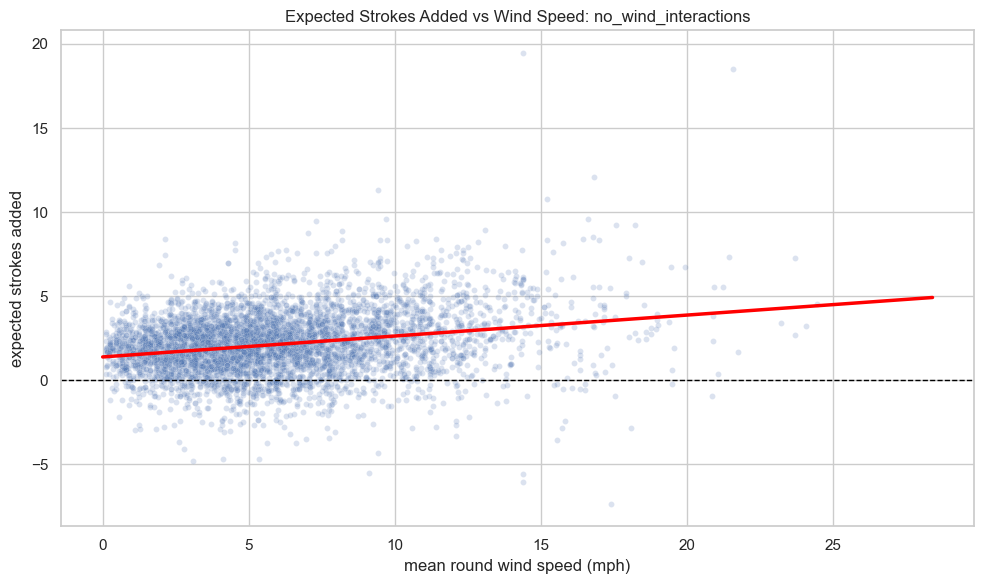

In [65]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added vs wind speed with fitted line
# -----------------------------------------------------------------------------

plot_sample_df = sensitivity_df.sample(min(5000, len(sensitivity_df)), random_state=RANDOM_STATE).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_sample_df,
    x="round_wind_speed_mph_mean",
    y="estimated_wind_impact_strokes",
    alpha=0.20,
    s=18,
)
sns.lineplot(
    data=wind_line_df,
    x="round_wind_speed_mph_mean",
    y="predicted_expected_strokes_added",
    color="red",
    linewidth=2.5,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added vs Wind Speed: {preferred_experiment}")
plt.xlabel("mean round wind speed (mph)")
plt.ylabel("expected strokes added")
plt.tight_layout()
plt.show()


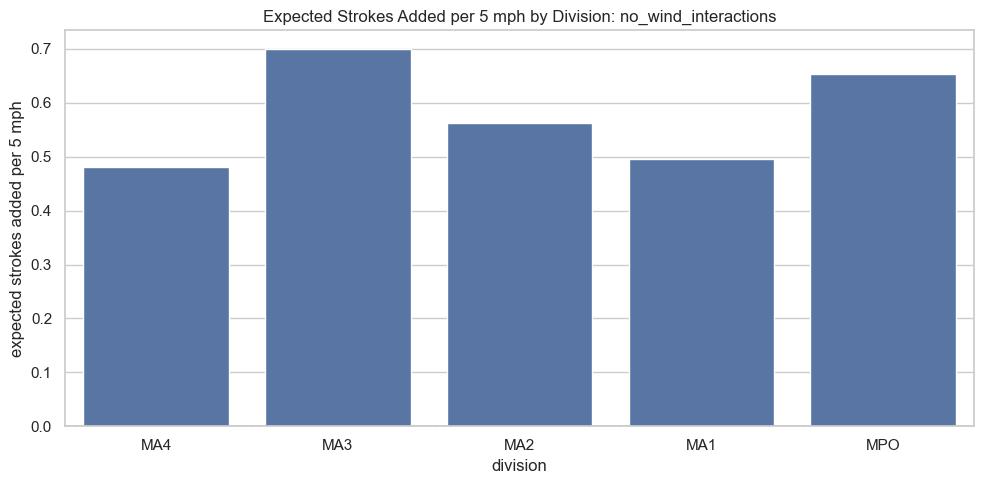

In [68]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added per 5 mph by division
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=division_wind_slopes_df,
    x="division",
    y="slope_per_5mph",
    order=DIVISION_ORDER,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added per 5 mph by Division: {preferred_experiment}")
plt.xlabel("division")
plt.ylabel("expected strokes added per 5 mph")
plt.tight_layout()
plt.show()


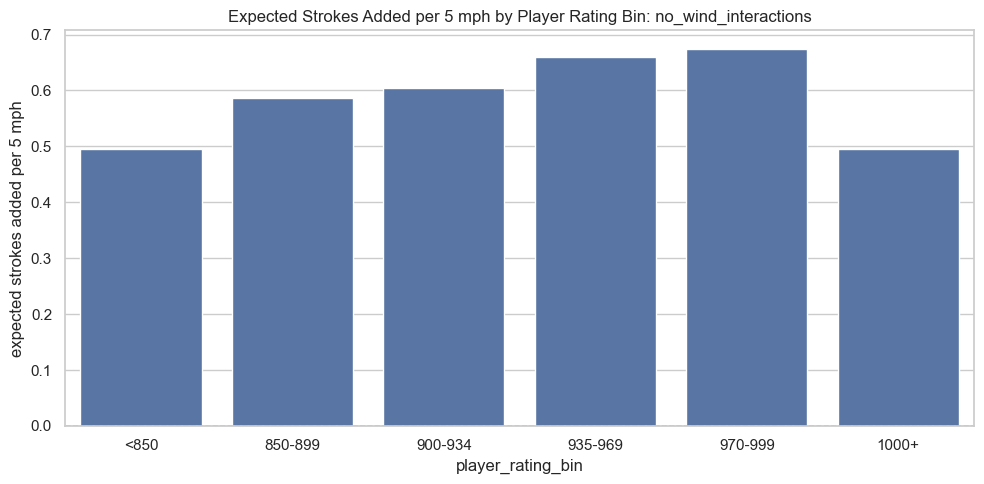

In [69]:
# -----------------------------------------------------------------------------
# Plot: expected strokes added per 5 mph by player rating bin
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 5))
sns.barplot(
    data=rating_wind_slopes_df,
    x="player_rating_bin",
    y="slope_per_5mph",
    order=PLAYER_RATING_BIN_LABELS,
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Expected Strokes Added per 5 mph by Player Rating Bin: {preferred_experiment}")
plt.xlabel("player_rating_bin")
plt.ylabel("expected strokes added per 5 mph")
plt.tight_layout()
plt.show()


In [75]:
# -----------------------------------------------------------------------------
# Course-level wind sensitivity slopes
# -----------------------------------------------------------------------------

MIN_COURSE_ROWS_FOR_SLOPE = 150
MIN_COURSE_WIND_STD_MPH = 2.0

course_slope_rows = []

course_sensitivity_df = preferred_scored_df.dropna(
    subset=[
        "course_id",
        "estimated_wind_impact_strokes",
        "round_wind_speed_mph_mean",
    ]
).copy()

course_sensitivity_df["course_id"] = course_sensitivity_df["course_id"].astype("string")

for course_id, course_df in course_sensitivity_df.groupby("course_id", dropna=False):
    course_df = course_df.copy()

    if len(course_df) < MIN_COURSE_ROWS_FOR_SLOPE:
        continue

    wind_std = course_df["round_wind_speed_mph_mean"].std()
    if pd.isna(wind_std) or wind_std < MIN_COURSE_WIND_STD_MPH:
        continue

    model = smf.ols(
        formula="estimated_wind_impact_strokes ~ round_wind_speed_mph_mean",
        data=course_df,
    ).fit()

    slope_per_mph = model.params["round_wind_speed_mph_mean"]
    slope_per_5mph = slope_per_mph * 5.0

    course_slope_rows.append(
        {
            "course_id": str(course_id),
            "rows": len(course_df),
            "wind_speed_mph_mean": course_df["round_wind_speed_mph_mean"].mean(),
            "wind_speed_mph_std": wind_std,
            "estimated_wind_impact_mean": course_df["estimated_wind_impact_strokes"].mean(),
            "slope_per_mph": slope_per_mph,
            "slope_per_5mph": slope_per_5mph,
            "intercept": model.params["Intercept"],
            "r_squared": model.rsquared,
        }
    )

course_wind_slopes_df = (
    pd.DataFrame(course_slope_rows)
    .sort_values(["slope_per_5mph", "rows"], ascending=[False, False])
    .reset_index(drop=True)
)

course_wind_slopes_df.head(20)


,course_id,rows,wind_speed_mph_mean,wind_speed_mph_std,estimated_wind_impact_mean,slope_per_mph,slope_per_5mph,intercept,r_squared
0,269721,151,6.317652,2.991733,2.957039,0.393942,1.969710,0.468251,0.306210
1,203716,168,6.187270,2.745166,2.533814,0.305091,1.525453,0.646137,0.174572
2,303867,165,8.507286,3.978744,5.195376,0.271439,1.357196,2.886165,0.238306
3,303953,187,7.113350,2.642447,2.639789,0.269771,1.348853,0.720817,0.154990
4,27727,197,4.720965,2.005379,2.204422,0.242954,1.214772,1.057443,0.117301
5,-1,5045,6.190963,4.051488,2.506597,0.183183,0.915916,1.372517,0.135498
6,28256,163,5.020764,2.422366,1.941971,0.173893,0.869466,1.068895,0.110185
7,231371,168,6.380206,3.704700,3.771200,0.164366,0.821830,2.722512,0.104110
8,28217,161,7.222815,4.375758,1.987085,0.134746,0.673729,1.013842,0.114942
9,204286,427,5.862774,2.512032,2.054959,0.125171,0.625857,1.321108,0.043154


In [76]:
# -----------------------------------------------------------------------------
# Inspect top and bottom courses by wind sensitivity
# -----------------------------------------------------------------------------

top_wind_sensitive_courses_df = course_wind_slopes_df.head(20).copy()
least_wind_sensitive_courses_df = course_wind_slopes_df.sort_values(
    ["slope_per_5mph", "rows"],
    ascending=[True, False],
).head(20).reset_index(drop=True)

top_wind_sensitive_courses_df, least_wind_sensitive_courses_df


(   course_id  rows  wind_speed_mph_mean  wind_speed_mph_std  \
 0     269721   151             6.317652            2.991733   
 1     203716   168             6.187270            2.745166   
 2     303867   165             8.507286            3.978744   
 3     303953   187             7.113350            2.642447   
 4      27727   197             4.720965            2.005379   
 5         -1  5045             6.190963            4.051488   
 6      28256   163             5.020764            2.422366   
 7     231371   168             6.380206            3.704700   
 8      28217   161             7.222815            4.375758   
 9     204286   427             5.862774            2.512032   
 10    222206   178             4.181067            2.865324   
 11     24820   194             5.946455            2.566989   
 12    201931   188            10.366789            4.251481   
 13    264496   212             7.001833            3.247411   
 14    212581   239             4.389269

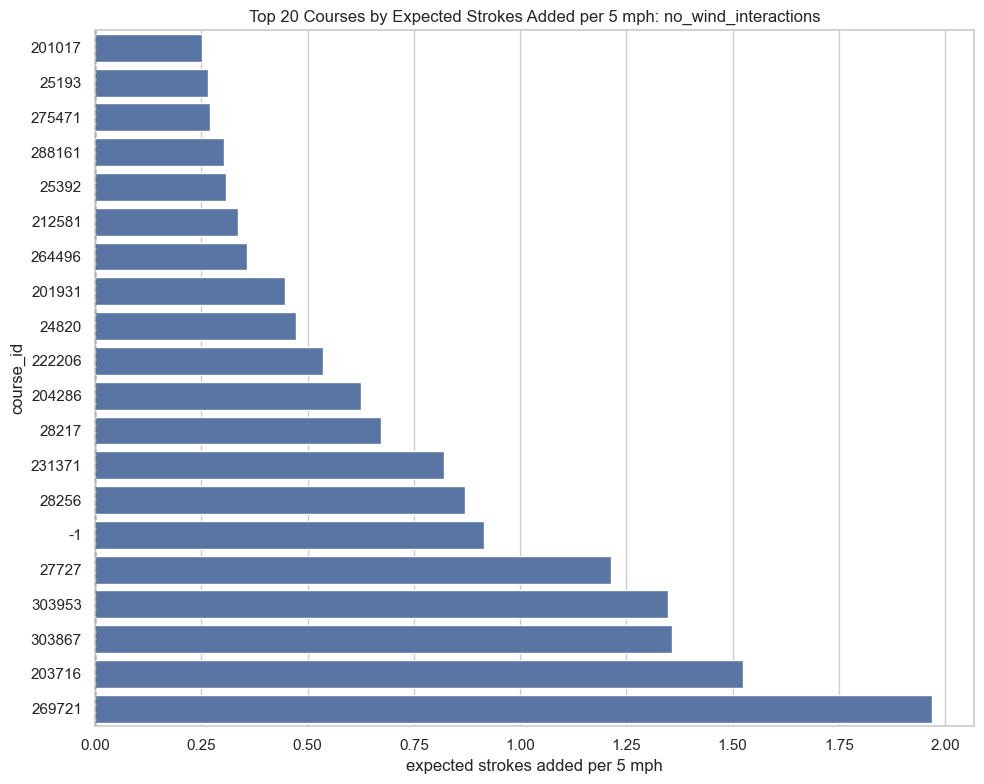

In [77]:
# -----------------------------------------------------------------------------
# Plot: top 20 most wind-sensitive courses
# -----------------------------------------------------------------------------

plot_df = top_wind_sensitive_courses_df.copy().iloc[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df,
    x="slope_per_5mph",
    y="course_id",
)
plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Top 20 Courses by Expected Strokes Added per 5 mph: {preferred_experiment}")
plt.xlabel("expected strokes added per 5 mph")
plt.ylabel("course_id")
plt.tight_layout()
plt.show()


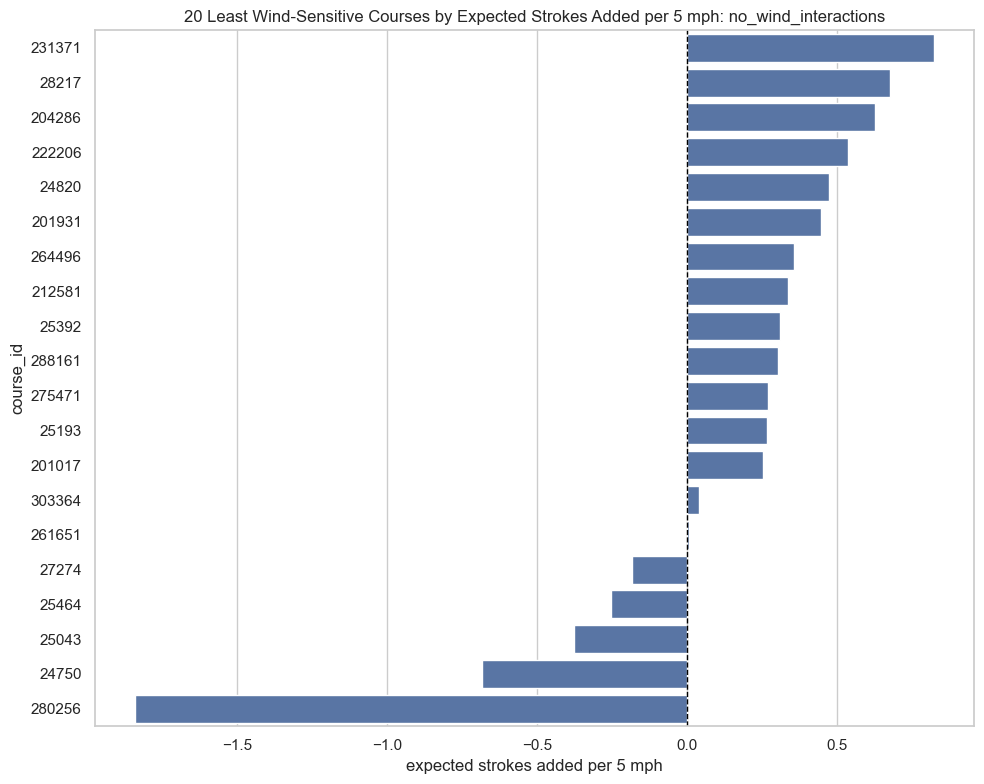

In [78]:
# -----------------------------------------------------------------------------
# Plot: 20 least wind-sensitive courses
# -----------------------------------------------------------------------------

plot_df = least_wind_sensitive_courses_df.copy().iloc[::-1]

plt.figure(figsize=(10, 8))
sns.barplot(
    data=plot_df,
    x="slope_per_5mph",
    y="course_id",
)
plt.axvline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"20 Least Wind-Sensitive Courses by Expected Strokes Added per 5 mph: {preferred_experiment}")
plt.xlabel("expected strokes added per 5 mph")
plt.ylabel("course_id")
plt.tight_layout()
plt.show()


In [88]:
# -----------------------------------------------------------------------------
# Optional quality filter: stronger-confidence course list
# -----------------------------------------------------------------------------

high_confidence_course_wind_slopes_df = course_wind_slopes_df[
    (course_wind_slopes_df["rows"] >= 50) &
    (course_wind_slopes_df["wind_speed_mph_std"] >= 1.0)
].copy().reset_index(drop=True)

high_confidence_course_wind_slopes_df


,course_id,rows,wind_speed_mph_mean,wind_speed_mph_std,estimated_wind_impact_mean,slope_per_mph,slope_per_5mph,intercept,r_squared
0,269721,151,6.317652,2.991733,2.957039,0.393942,1.969710,0.468251,0.306210
1,203716,168,6.187270,2.745166,2.533814,0.305091,1.525453,0.646137,0.174572
2,303867,165,8.507286,3.978744,5.195376,0.271439,1.357196,2.886165,0.238306
3,303953,187,7.113350,2.642447,2.639789,0.269771,1.348853,0.720817,0.154990
4,27727,197,4.720965,2.005379,2.204422,0.242954,1.214772,1.057443,0.117301
5,-1,5045,6.190963,4.051488,2.506597,0.183183,0.915916,1.372517,0.135498
6,28256,163,5.020764,2.422366,1.941971,0.173893,0.869466,1.068895,0.110185
7,231371,168,6.380206,3.704700,3.771200,0.164366,0.821830,2.722512,0.104110
8,28217,161,7.222815,4.375758,1.987085,0.134746,0.673729,1.013842,0.114942
9,204286,427,5.862774,2.512032,2.054959,0.125171,0.625857,1.321108,0.043154


In [90]:
# -----------------------------------------------------------------------------
# Recover the model-ready analysis frame for PDP-style scoring
# -----------------------------------------------------------------------------

preferred_experiment = "no_wind_interactions"
preferred_payload = experiment_scored_outputs[preferred_experiment]

preferred_model = preferred_payload["model"]
preferred_feature_cols = preferred_payload["feature_cols"]

pdp_base_df = preferred_payload["scored_df"].copy()

print("Using experiment:", preferred_experiment)
print("Rows in PDP base frame:", len(pdp_base_df))
pdp_base_df.head()



Using experiment: no_wind_interactions
Rows in PDP base frame: 83969


,event_year,tourn_id,round_number,player_key,course_id,layout_id,division,player_rating,actual_round_strokes,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,round_strokes_over_par,round_length_over_par,wind_x_round_length,gust_x_round_length,wind_x_player_rating,round_wind_speed_bucket,round_wind_gust_bucket,predicted_round_strokes,round_residual_strokes,predicted_round_strokes_calm_counterfactual,estimated_wind_impact_strokes
405787,2025,95243,1,PDGA#150233,240431,733407,MA3,853.0,82.0,22,7047.0,320.318182,71.0,3.227273,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,11.0,99.253521,29245.05,52852.5,3539.95,light,high,83.094866,-1.094866,77.711009,5.383857
163523,2026,97670,2,PDGA#320120,24750,740810,MA40,744.0,111.0,18,10780.0,598.888889,70.0,3.888889,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,41.0,154.000000,31262.00,61446.0,2157.60,light,mild,105.765377,5.234623,104.858872,0.906505
145680,2025,93650,1,PDGA#213243,25329,716237,MPO,1000.0,50.0,18,4426.0,245.888889,54.0,3.000000,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,-4.0,81.962963,12569.84,26998.6,2840.00,light,high,45.010946,4.989054,43.329906,1.681040
193881,2025,98617,1,PDGA#20175,204286,739590,MP50,896.0,60.0,18,5516.0,306.444444,57.0,3.166667,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,3.0,96.771930,19802.44,39715.2,3216.64,light,high,58.514905,1.485095,55.748940,2.765965
21439,2025,94448,1,PDGA#190976,303567,727345,MA2,911.0,73.0,18,7397.0,410.944444,64.0,3.555556,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,9.0,115.578125,10873.59,21451.3,1339.17,calm,low,69.941372,3.058628,65.791405,4.149967


In [92]:
# -----------------------------------------------------------------------------
# Recreate a CatBoost-ready feature frame from the scored output
# -----------------------------------------------------------------------------

pdp_feature_df = pdp_base_df.copy()

# Ensure categorical columns are string-like
for col in ["course_id", "layout_id", "division", "round_wind_speed_bucket", "round_wind_gust_bucket"]:
    if col in pdp_feature_df.columns:
        pdp_feature_df[col] = pdp_feature_df[col].astype("string")

# Ensure numeric columns are numeric
for col in preferred_feature_cols:
    if col in pdp_feature_df.columns and col not in ["course_id", "layout_id", "division", "round_wind_speed_bucket", "round_wind_gust_bucket"]:
        pdp_feature_df[col] = pd.to_numeric(pdp_feature_df[col], errors="coerce")

print("PDP feature frame shape:", pdp_feature_df.shape)
pdp_feature_df[preferred_feature_cols].head()




PDP feature frame shape: (83969, 34)


,player_rating,round_number,hole_count,round_total_hole_length,round_avg_hole_length,round_total_par,round_avg_hole_par,round_length_over_par,round_wind_speed_mps_mean,round_wind_speed_mps_max,round_wind_gust_mps_mean,round_wind_gust_mps_max,round_temp_c_mean,round_precip_mm_sum,round_precip_mm_mean,round_pressure_hpa_mean,round_humidity_pct_mean,course_id,round_wind_speed_bucket,round_wind_gust_bucket,division,layout_id
405787,853.0,1,22,7047.0,320.318182,71.0,3.227273,99.253521,4.15,4.15,7.5,7.5,15.4,0.0,0.0,1020.2,61.0,240431,light,high,MA3,733407
163523,744.0,2,18,10780.0,598.888889,70.0,3.888889,154.000000,2.90,2.90,5.7,5.7,18.4,0.0,0.0,1017.3,32.0,24750,light,mild,MA40,740810
145680,1000.0,1,18,4426.0,245.888889,54.0,3.000000,81.962963,2.84,2.84,6.1,6.1,26.1,1.8,0.1,1016.0,84.0,25329,light,high,MPO,716237
193881,896.0,1,18,5516.0,306.444444,57.0,3.166667,96.771930,3.59,3.59,7.2,7.2,-1.1,0.0,0.0,1014.8,87.0,204286,light,high,MP50,739590
21439,911.0,1,18,7397.0,410.944444,64.0,3.555556,115.578125,1.47,1.47,2.9,2.9,15.8,0.0,0.0,1018.3,84.0,303567,calm,low,MA2,727345


In [93]:
# -----------------------------------------------------------------------------
# Build train category levels for safe CatBoost scoring
# -----------------------------------------------------------------------------

# We need the training-prepped categories so new PDP rows stay valid.
# Reuse the training split and feature definitions from the winning experiment.

winning_experiment_config = None
for experiment in EXPERIMENTS:
    if experiment["name"] == preferred_experiment:
        winning_experiment_config = experiment
        break

if winning_experiment_config is None:
    raise ValueError(f"Could not find experiment config for {preferred_experiment}")

(
    winning_train_prepped,
    winning_valid_prepped,
    winning_test_prepped,
    winning_train_pool,
    winning_valid_pool,
    winning_test_pool,
    winning_feature_cols_check,
    winning_cat_idx,
) = prepare_catboost_frame(
    train_df=train_df,
    valid_df=valid_df,
    test_df=test_df,
    numeric_features=winning_experiment_config["numeric_features"],
    categorical_features=winning_experiment_config["categorical_features"],
    target_col="actual_round_strokes",
)

if winning_feature_cols_check != preferred_feature_cols:
    raise ValueError("Feature columns do not match the preferred model feature columns.")

train_category_levels = {}
for col in winning_experiment_config["categorical_features"]:
    train_category_levels[col] = set(winning_train_prepped[col].astype(str).unique())

print("Winning categorical features:", winning_experiment_config["categorical_features"])

Winning categorical features: ['course_id', 'round_wind_speed_bucket', 'round_wind_gust_bucket', 'division', 'layout_id']


In [94]:
# -----------------------------------------------------------------------------
# PDP-style scoring helper for wind speed
# -----------------------------------------------------------------------------

MPS_TO_MPH = 2.23694
MPH_TO_MPS = 1.0 / MPS_TO_MPH

def score_wind_speed_counterfactual(
    base_df: pd.DataFrame,
    model: CatBoostRegressor,
    feature_cols: list[str],
    categorical_features: list[str],
    cat_idx: list[int],
    train_category_levels: dict[str, set[str]],
    wind_speed_mph: float,
    gust_multiplier: float = 1.35,
) -> pd.DataFrame:
    """
    Re-score all rows after setting wind-speed-related fields to a chosen wind speed.
    Keeps all non-wind context fixed. This is a partial-dependence-style intervention.
    """

    df = base_df.copy()

    wind_speed_mps = wind_speed_mph * MPH_TO_MPS
    wind_gust_mps = wind_speed_mps * gust_multiplier

    if "round_wind_speed_mps_mean" in df.columns:
        df["round_wind_speed_mps_mean"] = wind_speed_mps
    if "round_wind_speed_mps_max" in df.columns:
        df["round_wind_speed_mps_max"] = wind_speed_mps
    if "round_wind_gust_mps_mean" in df.columns:
        df["round_wind_gust_mps_mean"] = wind_gust_mps
    if "round_wind_gust_mps_max" in df.columns:
        df["round_wind_gust_mps_max"] = wind_gust_mps

    if "round_wind_speed_bucket" in df.columns:
        df["round_wind_speed_bucket"] = wind_speed_bucket(wind_speed_mps)
    if "round_wind_gust_bucket" in df.columns:
        df["round_wind_gust_bucket"] = wind_gust_bucket(wind_gust_mps)

    # Rebuild interaction terms if they exist in the model.
    if "wind_x_round_length" in df.columns:
        df["wind_x_round_length"] = df["round_wind_speed_mps_mean"] * df["round_total_hole_length"]
    if "gust_x_round_length" in df.columns:
        df["gust_x_round_length"] = df["round_wind_gust_mps_mean"] * df["round_total_hole_length"]
    if "wind_x_player_rating" in df.columns:
        df["wind_x_player_rating"] = df["round_wind_speed_mps_mean"] * df["player_rating"]

    # Safe categorical handling
    for col in categorical_features:
        df[col] = df[col].astype("string").fillna("__MISSING__").astype(str)
        allowed_levels = train_category_levels[col]
        df[col] = df[col].where(df[col].isin(allowed_levels), "__MISSING__")

    pdp_pool = Pool(
        data=df[feature_cols],
        cat_features=cat_idx,
    )

    scored_df = df.copy()
    scored_df["pdp_predicted_round_strokes"] = model.predict(pdp_pool)
    scored_df["pdp_wind_speed_mph"] = wind_speed_mph

    return scored_df

In [95]:
# -----------------------------------------------------------------------------
# Score a wind-speed grid
# -----------------------------------------------------------------------------

WIND_SPEED_GRID_MPH = list(range(0, 31, 2))

pdp_frames = []

for wind_speed_mph in WIND_SPEED_GRID_MPH:
    scored_df = score_wind_speed_counterfactual(
        base_df=pdp_feature_df,
        model=preferred_model,
        feature_cols=preferred_feature_cols,
        categorical_features=winning_experiment_config["categorical_features"],
        cat_idx=winning_cat_idx,
        train_category_levels=train_category_levels,
        wind_speed_mph=wind_speed_mph,
        gust_multiplier=1.35,
    )
    pdp_frames.append(scored_df)

wind_pdp_scored_df = pd.concat(pdp_frames, ignore_index=True)

print("PDP scored shape:", wind_pdp_scored_df.shape)
wind_pdp_scored_df[["pdp_wind_speed_mph", "pdp_predicted_round_strokes"]].head()

PDP scored shape: (1343504, 36)


,pdp_wind_speed_mph,pdp_predicted_round_strokes
0,0,77.711009
1,0,104.858872
2,0,42.920422
3,0,55.748940
4,0,65.791405


In [96]:
# -----------------------------------------------------------------------------
# Summarize the PDP-style wind curve
# -----------------------------------------------------------------------------

wind_pdp_curve_df = (
    wind_pdp_scored_df.groupby("pdp_wind_speed_mph", as_index=False)
    .agg(
        rows=("pdp_predicted_round_strokes", "size"),
        predicted_round_strokes_mean=("pdp_predicted_round_strokes", "mean"),
    )
    .sort_values("pdp_wind_speed_mph")
    .reset_index(drop=True)
)

baseline_pred_at_0_mph = float(
    wind_pdp_curve_df.loc[
        wind_pdp_curve_df["pdp_wind_speed_mph"] == 0,
        "predicted_round_strokes_mean",
    ].iloc[0]
)

wind_pdp_curve_df["expected_strokes_added_vs_0mph"] = (
    wind_pdp_curve_df["predicted_round_strokes_mean"] - baseline_pred_at_0_mph
)

wind_pdp_curve_df["expected_strokes_added_per_5mph_from_0"] = np.where(
    wind_pdp_curve_df["pdp_wind_speed_mph"] > 0,
    wind_pdp_curve_df["expected_strokes_added_vs_0mph"] / wind_pdp_curve_df["pdp_wind_speed_mph"] * 5.0,
    np.nan,
)

wind_pdp_curve_df

,pdp_wind_speed_mph,rows,predicted_round_strokes_mean,expected_strokes_added_vs_0mph,expected_strokes_added_per_5mph_from_0
0,0,83969,60.265186,0.000000,NaN
1,2,83969,61.435094,1.169907,2.924769
2,4,83969,62.104913,1.839727,2.299659
3,6,83969,62.367691,2.102505,1.752087
4,8,83969,62.705645,2.440458,1.525287
5,10,83969,62.707351,2.442164,1.221082
6,12,83969,63.388188,3.123002,1.301251
7,14,83969,64.419202,4.154016,1.483577
8,16,83969,63.651005,3.385819,1.058068
9,18,83969,63.312989,3.047802,0.846612


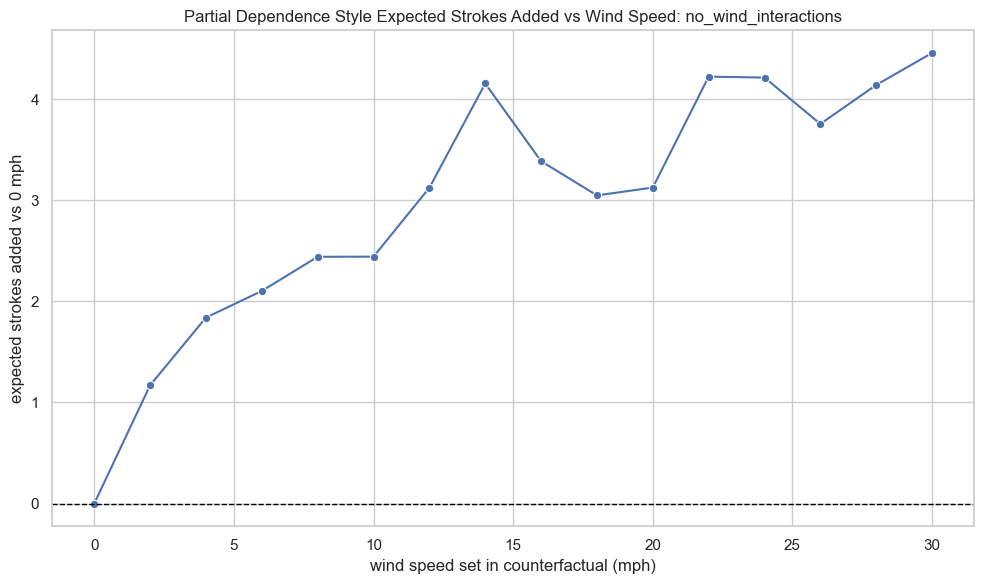

In [97]:
# -----------------------------------------------------------------------------
# Plot: partial dependence style expected strokes added vs wind speed
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=wind_pdp_curve_df,
    x="pdp_wind_speed_mph",
    y="expected_strokes_added_vs_0mph",
    marker="o",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Partial Dependence Style Expected Strokes Added vs Wind Speed: {preferred_experiment}")
plt.xlabel("wind speed set in counterfactual (mph)")
plt.ylabel("expected strokes added vs 0 mph")
plt.tight_layout()
plt.show()

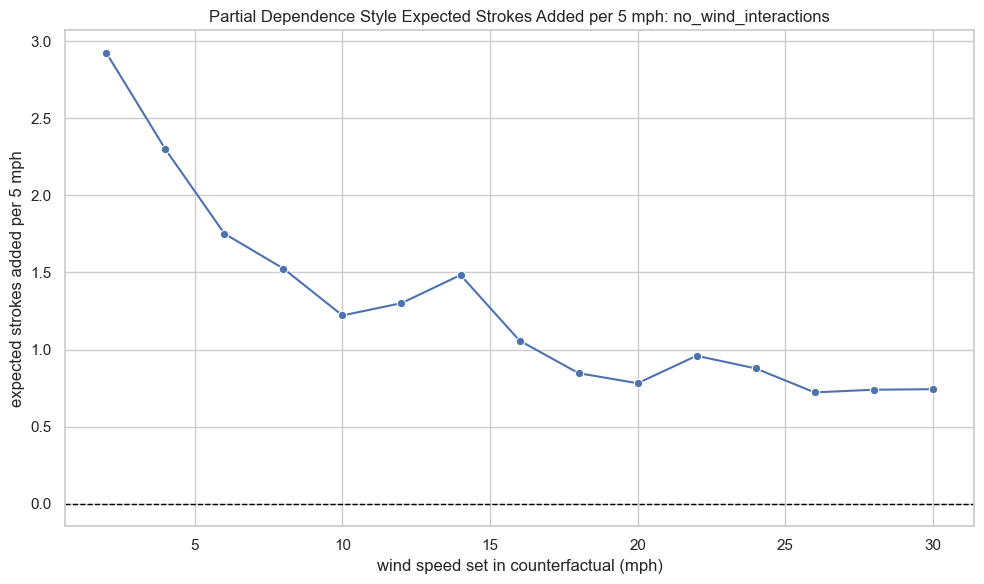

In [98]:
# -----------------------------------------------------------------------------
# Plot: partial dependence style expected strokes added per 5 mph
# -----------------------------------------------------------------------------

plt.figure(figsize=(10, 6))
sns.lineplot(
    data=wind_pdp_curve_df.dropna(subset=["expected_strokes_added_per_5mph_from_0"]),
    x="pdp_wind_speed_mph",
    y="expected_strokes_added_per_5mph_from_0",
    marker="o",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Partial Dependence Style Expected Strokes Added per 5 mph: {preferred_experiment}")
plt.xlabel("wind speed set in counterfactual (mph)")
plt.ylabel("expected strokes added per 5 mph")
plt.tight_layout()
plt.show()

In [99]:
# -----------------------------------------------------------------------------
# Optional: division-specific partial dependence wind curves
# -----------------------------------------------------------------------------

division_wind_pdp_curve_df = (
    wind_pdp_scored_df[
        wind_pdp_scored_df["division"].isin(DIVISION_ORDER)
    ]
    .groupby(["division", "pdp_wind_speed_mph"], as_index=False)
    .agg(
        predicted_round_strokes_mean=("pdp_predicted_round_strokes", "mean"),
        rows=("pdp_predicted_round_strokes", "size"),
    )
)

division_baseline_df = (
    division_wind_pdp_curve_df[division_wind_pdp_curve_df["pdp_wind_speed_mph"] == 0]
    [["division", "predicted_round_strokes_mean"]]
    .rename(columns={"predicted_round_strokes_mean": "baseline_pred_at_0mph"})
)

division_wind_pdp_curve_df = division_wind_pdp_curve_df.merge(
    division_baseline_df,
    on="division",
    how="left",
)

division_wind_pdp_curve_df["expected_strokes_added_vs_0mph"] = (
    division_wind_pdp_curve_df["predicted_round_strokes_mean"] -
    division_wind_pdp_curve_df["baseline_pred_at_0mph"]
)

division_wind_pdp_curve_df["division"] = pd.Categorical(
    division_wind_pdp_curve_df["division"],
    categories=DIVISION_ORDER,
    ordered=True,
)

division_wind_pdp_curve_df.head()

,division,pdp_wind_speed_mph,predicted_round_strokes_mean,rows,baseline_pred_at_0mph,expected_strokes_added_vs_0mph
0,MA1,0,57.539717,14030,57.539717,0.000000
1,MA1,2,59.064166,14030,57.539717,1.524448
2,MA1,4,59.688539,14030,57.539717,2.148822
3,MA1,6,60.047285,14030,57.539717,2.507568
4,MA1,8,60.425678,14030,57.539717,2.885961


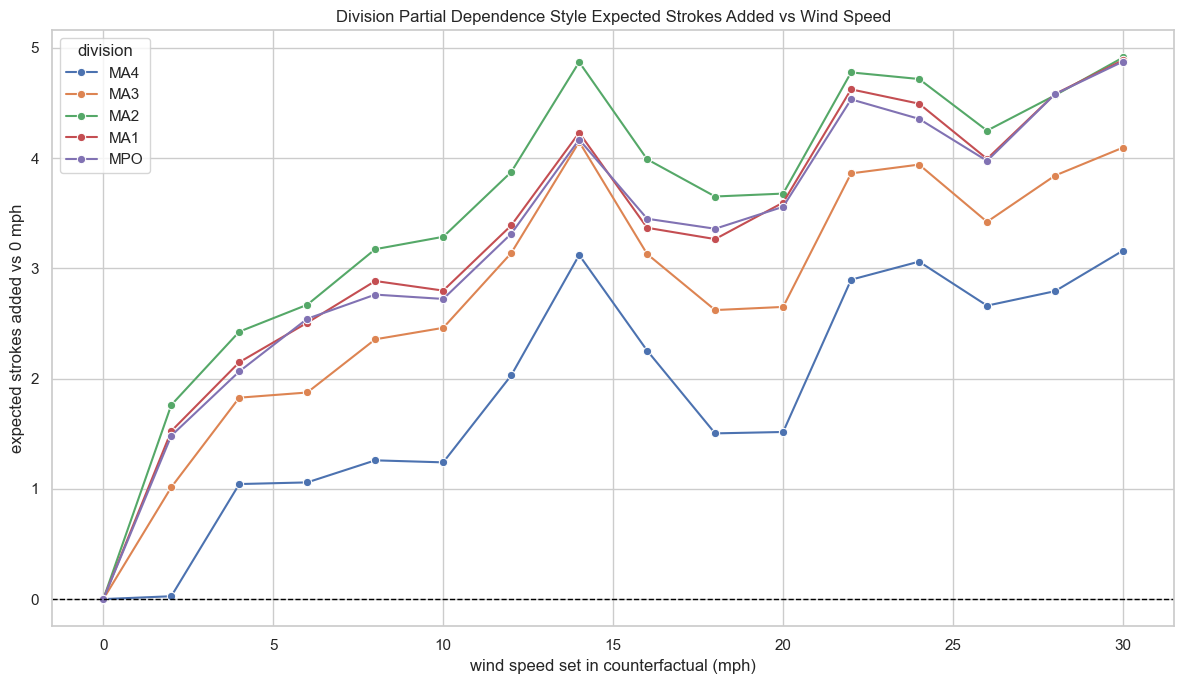

In [100]:
# -----------------------------------------------------------------------------
# Plot: division-specific partial dependence wind curves
# -----------------------------------------------------------------------------

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=division_wind_pdp_curve_df,
    x="pdp_wind_speed_mph",
    y="expected_strokes_added_vs_0mph",
    hue="division",
    hue_order=DIVISION_ORDER,
    marker="o",
)
plt.axhline(0.0, color="black", linestyle="--", linewidth=1)
plt.title(f"Division Partial Dependence Style Expected Strokes Added vs Wind Speed")
plt.xlabel("wind speed set in counterfactual (mph)")
plt.ylabel("expected strokes added vs 0 mph")
plt.tight_layout()
plt.show()